# Análise dos resultados dos experimentos

## Bibliotecas e configurações iniciais

In [ ]:
import os
# bibliotecas de dados
import pandas as pd
import numpy as np
# biblioteca de visualização
import seaborn as sns
import matplotlib.pyplot as plt
# estatística
import scipy.stats as stats

In [ ]:
# configuração de visualização
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 5)
# plt.style.use('seaborn-v0_8-whitegrid')
# sns.set_style('darkgrid')

## Carregamento dos dados

In [ ]:
#montar googledrive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
caminho_pasta_resultados = '/content/drive/MyDrive/xxxxxxxx/Resultados/'

caminho_emissoes_treino = os.path.join(caminho_pasta_resultados, 'emissoes_treino_total_unidades.csv')
caminho_emissoes_teste = os.path.join(caminho_pasta_resultados, 'emissoes_teste_total_unidades.csv')
caminho_resultado_inferencia = os.path.join(caminho_pasta_resultados, 'resultados_inferencia_total.csv')

In [ ]:
# from pandas.core.arrays.period import dt64arr_to_periodarr
# carregamento do dataset resultados da inferência
df_inferencia = pd.read_csv(caminho_resultado_inferencia, sep=';', decimal=',')

# Padronização de nomes
df_inferencia.rename(columns={'Precisão numérica': 'Precisão', 'Acurácia Teste': 'Accuracy',
                              'Precisão Teste': 'Precision', 'Recall Teste': 'Recall', 'F1 Score Teste': 'F1 Score'}, inplace=True)

# retirada das colunas desnecessárias
df_inferencia = df_inferencia.drop(columns=['Tempo Teste', 'Consumo Energia Teste', 'Emissões Teste'])

# Visualização inicial
display(df_inferencia.head())

,Arquitetura,Precisão,Accuracy,Precision,Recall,F1 Score
0,LeNet,FP32,0.7304,0.730583,0.7304,0.730132
1,LeNet,FP32,0.7295,0.729805,0.7295,0.729442
2,LeNet,FP32,0.7338,0.733813,0.7338,0.733519
3,LeNet,FP32,0.7292,0.729604,0.7292,0.729104
4,LeNet,FP32,0.7304,0.730388,0.7304,0.730150


In [ ]:
# Carregando os datasets treino e teste
# O parâmetro decimal=',' é crucial pois os dados usam vírgula como separador decimal
df_treino = pd.read_csv(caminho_emissoes_treino, sep=';', decimal=',')
df_teste = pd.read_csv(caminho_emissoes_teste, sep=';', decimal=',')

# df_teste.drop(columns=['ram_power', 'emissions'], inplace=True)
# df_treino.drop(columns=['emissions'], inplace=True)
df_teste.drop(columns=['ram_power'], inplace=True)

#exclusão colunas
colunas_para_excluir = ['carbono_g', 'emissions_rate', 'cpu_power', 'gpu_power', 'cpu_energy',
                        'gpu_energy', 'ram_energy', 'consumo_energia_wh', 'energia_W']

df_teste.drop(columns=colunas_para_excluir, inplace=True)
df_treino.drop(columns=colunas_para_excluir, inplace=True)

# criação de coluna com unidades alternativas KWh para Joule
df_treino['energy_consumed_joule'] = df_treino['energy_consumed'] * 3.6e6
df_teste['energy_consumed_joule'] = df_teste['energy_consumed'] * 3.6e6

# criação de coluna com unidades alternativas KWh para Wh
df_treino['energy_consumed_wh'] = df_treino['energy_consumed'] * 1000
df_teste['energy_consumed_wh'] = df_teste['energy_consumed'] * 1000

# criação de coluna com unidade alternativa de Kg de CO2 para g
df_treino['emissions_g'] = df_treino['emissions'] * 1000
df_teste['emissions_g'] = df_teste['emissions'] * 1000

# Verificação básica
print("Resumo Treino:")
display(df_treino.head())
print("\nResumo Teste:")
display(df_teste.head())

Resumo Treino:


,Arquitetura,Precisão,duration,emissions,energy_consumed,energy_consumed_joule,energy_consumed_wh,emissions_g
0,LeNet,FP32,204.543484,0.000743,0.007551,27184.8780,7.551355,0.742661
1,LeNet,FP32,234.942762,0.001084,0.011019,39667.1328,11.018648,1.083662
2,LeNet,FP32,232.213766,0.000711,0.007229,26023.4172,7.228727,0.710931
3,LeNet,FP32,233.011972,0.000782,0.007948,28611.1224,7.947534,0.781624
4,LeNet,FP32,232.581632,0.001016,0.010328,37179.3852,10.327607,1.015700



Resumo Teste:


,Arquitetura,Precisão,duration,emissions,energy_consumed,energy_consumed_joule,energy_consumed_wh,emissions_g
0,LeNet,FP32,0.865020,0.000005,0.000050,180.00,0.0500,0.00492
1,LeNet,FP32,0.860128,0.000002,0.000022,78.48,0.0218,0.00214
2,LeNet,FP32,0.876303,0.000004,0.000041,147.24,0.0409,0.00403
3,LeNet,FP32,0.882100,0.000005,0.000052,187.92,0.0522,0.00513
4,LeNet,FP32,0.877114,0.000003,0.000034,123.84,0.0344,0.00338


In [ ]:
# trocar nome darquitetura GoogLeNet  para Inception
df_treino['Arquitetura'] = df_treino['Arquitetura'].replace('GoogLeNet', 'Inception')
df_teste['Arquitetura'] = df_teste['Arquitetura'].replace('GoogLeNet', 'Inception')

Dicionário dos dados de saída: https://mlco2.github.io/codecarbon/output.html

Unidades das Medições
* Duração (duration) → segundos (s)
* Emissões (emissions) → CO₂-equivalents [CO₂eq], em kg
* Energia consumida (energy_consumed) → Soma dos consumos de energia de cpu, gpu e ram em (kWh)

## Resumo estatístico

In [ ]:
# Agrupando por Arquitetura e Precisão para obter médias e desvios padrão
cols_interesse = ['duration', 'emissions', 'energy_consumed']

resumo_treino = df_treino.groupby(['Arquitetura', 'Precisão'])[cols_interesse].agg(['mean', 'std'])
print("Estatísticas de Treinamento:")
display(resumo_treino)

resumo_teste = df_teste.groupby(['Arquitetura', 'Precisão'])[cols_interesse].agg(['mean', 'std'])
print("\nEstatísticas de Teste:")
display(resumo_teste)

Estatísticas de Treinamento:


duration            emissions            \
                             mean        std      mean       std   
Arquitetura Precisão                                               
AlexNet     FP16      2013.509371   0.443834  0.009643  0.000184   
            FP32      2044.933401  24.714779  0.009688  0.000276   
Inception   FP16       618.150005   1.286327  0.003213  0.000395   
            FP32       986.538784   1.923693  0.004840  0.000070   
LeNet       FP16       206.331515   2.968899  0.000794  0.000083   
            FP32       231.074199   9.382704  0.000851  0.000154   
ResNet      FP16      3071.502118   0.700815  0.013889  0.000051   
            FP32      4499.224606   1.752307  0.020774  0.000184   
VGG         FP16      1911.054634   1.208308  0.008399  0.000055   
            FP32      2048.862586   2.045530  0.009268  0.000052   

                     energy_consumed            
                                mean       std  
Arquitetura Precisão                            
AlexNet     FP16            0.098050  0.001871  
            FP32            0.098512  0.002808  
Inception   FP16            0.032667  0.004018  
            FP32            0.049209  0.000716  
LeNet       FP16            0.008074  0.000843  
            FP32            0.008656  0.001569  
ResNet      FP16            0.141218  0.000514  
            FP32            0.211230  0.001873  
VGG         FP16            0.085403  0.000557  
            FP32            0.094234  0.000525


Estatísticas de Teste:


duration           emissions                \
                          mean       std      mean           std   
Arquitetura Precisão                                               
AlexNet     FP16      1.375519  0.009736  0.000007  8.285389e-07   
            FP32      1.450376  0.012210  0.000007  7.148776e-07   
Inception   FP16      1.108399  0.008024  0.000007  1.169028e-06   
            FP32      1.660287  0.012281  0.000009  8.077878e-07   
LeNet       FP16      0.871730  0.008387  0.000003  5.776283e-07   
            FP32      0.868629  0.008202  0.000003  1.065585e-06   
ResNet      FP16      3.839927  0.008336  0.000020  3.206313e-06   
            FP32      5.867331  0.011060  0.000030  3.577336e-06   
VGG         FP16      1.538737  0.007204  0.000008  1.409876e-06   
            FP32      1.784686  0.007584  0.000009  1.474880e-06   

                     energy_consumed            
                                mean       std  
Arquitetura Precisão                            
AlexNet     FP16            0.000068  0.000008  
            FP32            0.000074  0.000007  
Inception   FP16            0.000069  0.000012  
            FP32            0.000088  0.000008  
LeNet       FP16            0.000032  0.000006  
            FP32            0.000034  0.000011  
ResNet      FP16            0.000204  0.000033  
            FP32            0.000304  0.000037  
VGG         FP16            0.000080  0.000014  
            FP32            0.000093  0.000015

In [ ]:
# Agrupando por Arquitetura e Precisão para obter médias e desvios padrão usando unidades alternativas
cols_interesse_mul = ['energy_consumed_joule', 'energy_consumed_wh', 'emissions_g']

resumo_treino = df_treino.groupby(['Arquitetura', 'Precisão'])[cols_interesse_mul].agg(['mean', 'std'])
print("Estatísticas de Treinamento:")
display(resumo_treino)

resumo_teste = df_teste.groupby(['Arquitetura', 'Precisão'])[cols_interesse_mul].agg(['mean', 'std'])
print("\nEstatísticas de Teste:")
display(resumo_teste)

Estatísticas de Treinamento:


energy_consumed_joule               energy_consumed_wh  \
                                      mean           std               mean   
Arquitetura Precisão                                                          
AlexNet     FP16              352980.33480   6737.063555          98.050093   
            FP32              354642.43104  10110.095271          98.511786   
Inception   FP16              117600.22044  14464.396349          32.666728   
            FP32              177150.95352   2577.675375          49.208598   
LeNet       FP16               29067.17832   3034.298106           8.074216   
            FP32               31159.81800   5648.401674           8.655505   
ResNet      FP16              508384.59048   1848.897569         141.217942   
            FP32              760428.74988   6741.223755         211.230208   
VGG         FP16              307452.09672   2003.923451          85.403360   
            FP32              339241.95720   1890.793685          94.233877   

                               emissions_g            
                           std        mean       std  
Arquitetura Precisão                                  
AlexNet     FP16      1.871407    9.643031  0.184049  
            FP32      2.808360    9.688437  0.276197  
Inception   FP16      4.017888    3.212707  0.395151  
            FP32      0.716021    4.839567  0.070419  
LeNet       FP16      0.842861    0.794083  0.082894  
            FP32      1.569000    0.851252  0.154308  
ResNet      FP16      0.513583   13.888502  0.050510  
            FP32      1.872562   20.774069  0.184163  
VGG         FP16      0.556645    8.399250  0.054745  
            FP32      0.525220    9.267713  0.051654


Estatísticas de Teste:


energy_consumed_joule             energy_consumed_wh  \
                                      mean         std               mean   
Arquitetura Precisão                                                        
AlexNet     FP16                  243.3960   30.268296           0.067610   
            FP32                  265.2840   26.153091           0.073690   
Inception   FP16                  247.2480   42.780900           0.068680   
            FP32                  315.0720   29.576921           0.087520   
LeNet       FP16                  113.5440   21.169850           0.031540   
            FP32                  120.9960   38.985579           0.033610   
ResNet      FP16                  734.1084  117.525910           0.203919   
            FP32                 1095.0480  131.415481           0.304180   
VGG         FP16                  289.4400   51.619531           0.080400   
            FP32                  334.0224   54.077372           0.092784   

                               emissions_g            
                           std        mean       std  
Arquitetura Precisão                                  
AlexNet     FP16      0.008408    0.006649  0.000829  
            FP32      0.007265    0.007245  0.000715  
Inception   FP16      0.011884    0.006754  0.001169  
            FP32      0.008216    0.008609  0.000808  
LeNet       FP16      0.005881    0.003101  0.000578  
            FP32      0.010829    0.003306  0.001066  
ResNet      FP16      0.032646    0.020060  0.003206  
            FP32      0.036504    0.029920  0.003577  
VGG         FP16      0.014339    0.007908  0.001410  
            FP32      0.015021    0.009126  0.001475

In [ ]:
resumo_teste.to_csv('resumo_teste.csv', sep=';', decimal=',', encoding='iso-8859-1')
resumo_treino.to_csv('resumo_treino.csv', sep=';', decimal=',', encoding='iso-8859-1')

In [ ]:
# Agrupando por Arquitetura e Precisão para obter médias e desvios padrão resultados
resumo_inferencia = df_inferencia.groupby(['Arquitetura', 'Precisão']).agg(['mean', 'std'])
print("Estatísticas de resultados:")
display(resumo_inferencia)

Estatísticas de resultados:


Accuracy           Precision             Recall  \
                         mean       std      mean       std     mean   
Arquitetura Precisão                                                   
AlexNet     FP16      0.83034  0.002047  0.830533  0.002034  0.83034   
            FP32      0.82856  0.001645  0.829362  0.001657  0.82856   
GoogLeNet   FP16      0.84267  0.001334  0.842443  0.001341  0.84267   
            FP32      0.84235  0.001849  0.842058  0.001858  0.84235   
LeNet       FP16      0.73721  0.001697  0.737372  0.001680  0.73721   
            FP32      0.73031  0.001897  0.730519  0.001819  0.73031   
ResNet      FP16      0.86341  0.000939  0.863883  0.000970  0.86341   
            FP32      0.87065  0.001374  0.870444  0.001354  0.87065   
VGG         FP16      0.86167  0.001448  0.861864  0.001391  0.86167   
            FP32      0.86035  0.001505  0.860703  0.001527  0.86035   

                                F1 Score            
                           std      mean       std  
Arquitetura Precisão                                
AlexNet     FP16      0.002047  0.830354  0.002042  
            FP32      0.001645  0.828841  0.001633  
GoogLeNet   FP16      0.001334  0.842469  0.001336  
            FP32      0.001849  0.842121  0.001850  
LeNet       FP16      0.001697  0.737088  0.001681  
            FP32      0.001897  0.730140  0.001846  
ResNet      FP16      0.000939  0.863549  0.000959  
            FP32      0.001374  0.870436  0.001378  
VGG         FP16      0.001448  0.861697  0.001422  
            FP32      0.001505  0.860429  0.001493

## Gráficos Treinamento

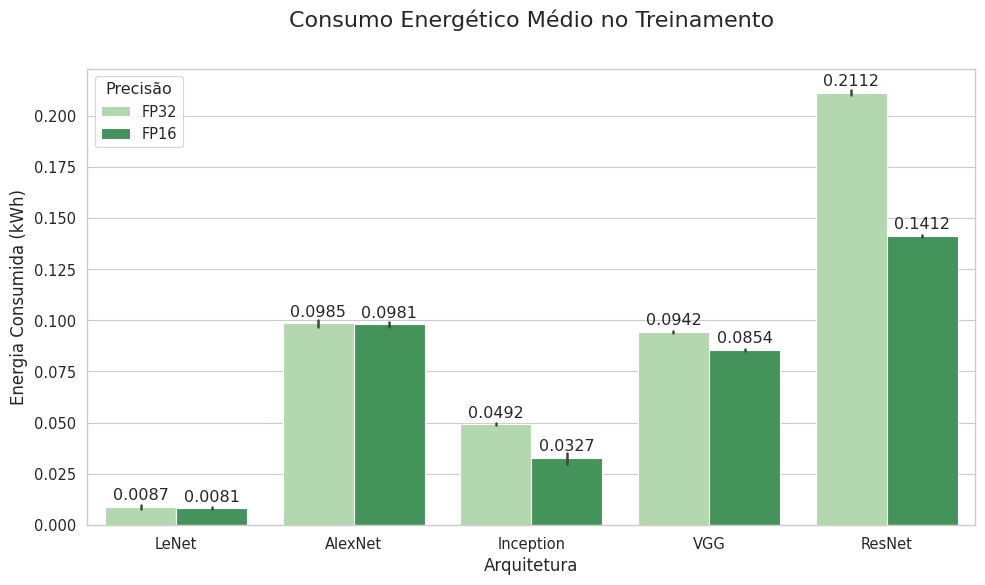

In [ ]:
# Gráfico de Barras: Energia por Arquitetura e Precisão
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_treino, x='Arquitetura', y='energy_consumed', hue='Precisão', palette='Greens')

plt.title('Consumo Energético Médio no Treinamento', fontsize=16, pad=30)
plt.ylabel('Energia Consumida (kWh)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)
plt.legend(title='Precisão')

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

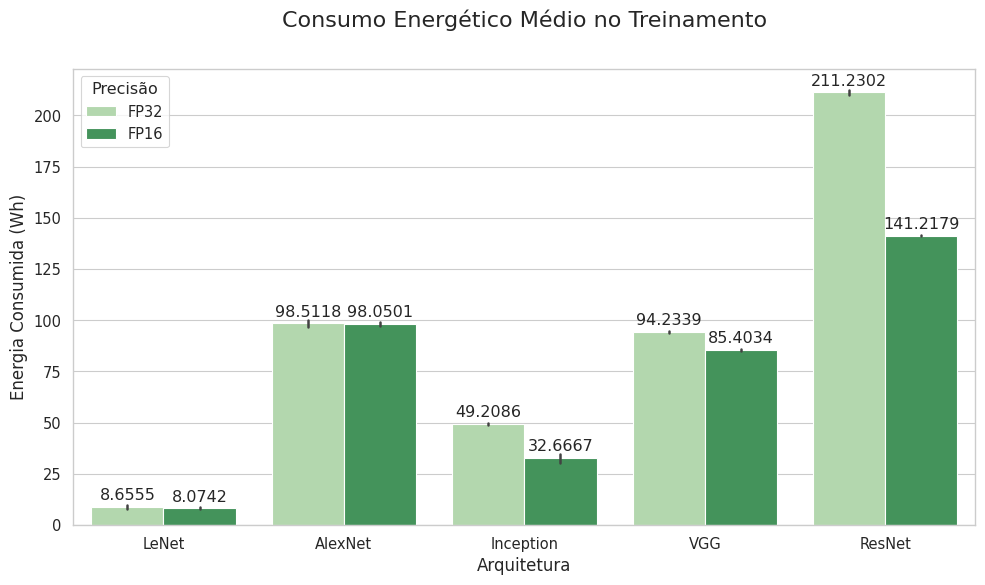

In [ ]:
# Gráfico de Barras: Energia por Arquitetura e Precisão
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_treino, x='Arquitetura', y='energy_consumed_wh', hue='Precisão', palette='Greens')

plt.title('Consumo Energético Médio no Treinamento', fontsize=16, pad=30)
plt.ylabel('Energia Consumida (Wh)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)
plt.legend(title='Precisão')

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

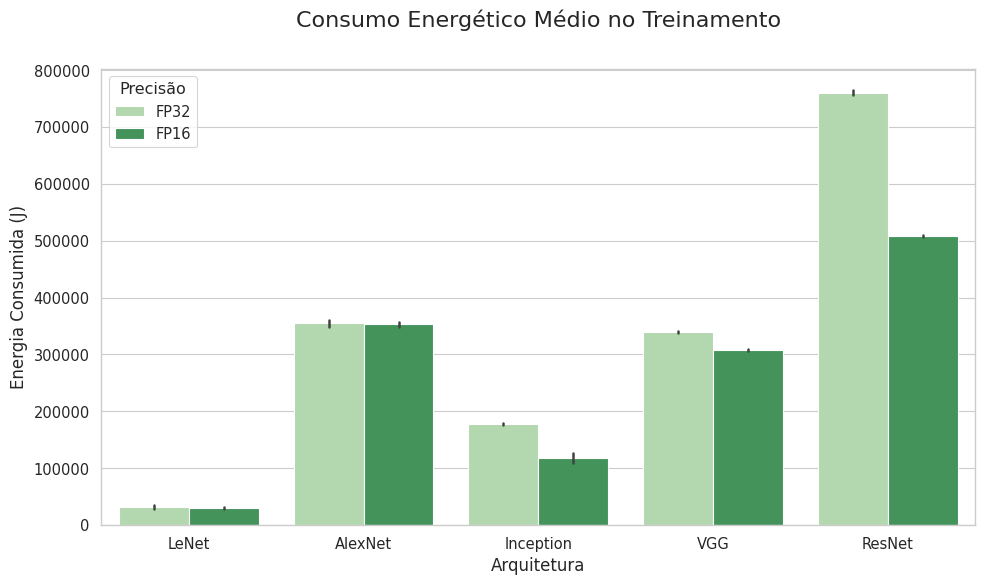

In [ ]:
# Gráfico de Barras: Energia por Arquitetura e Precisão
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_treino, x='Arquitetura', y='energy_consumed_joule', hue='Precisão', palette='Greens')

plt.title('Consumo Energético Médio no Treinamento', fontsize=16, pad=30)
plt.ylabel('Energia Consumida (J)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)
plt.legend(title='Precisão')

# # Adicionando valores nas barras
# for container in ax.containers:
#     ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

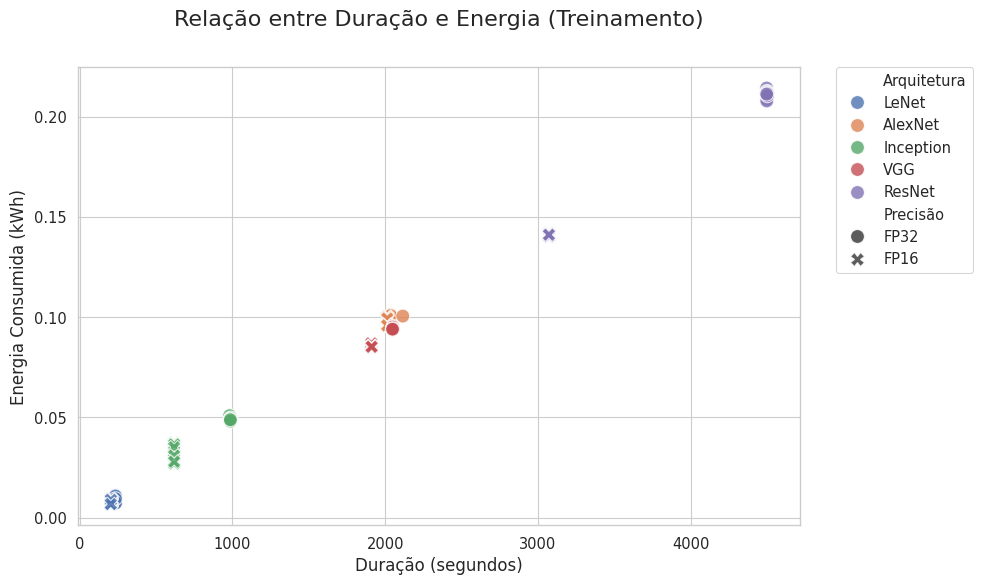

In [ ]:
# Scatter plot para visualizar a distribuição e relação linear
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_treino,
    x='duration',
    y='energy_consumed',
    hue='Arquitetura',
    style='Precisão',
    s=100, # Tamanho dos pontos
    alpha=0.8 # Transparência
)

plt.title('Relação entre Duração e Energia (Treinamento)', fontsize=16, pad=30)
plt.xlabel('Duração (segundos)', fontsize=12)
plt.ylabel('Energia Consumida (kWh)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

In [ ]:
# correlação linear entre consumo e tempo
correlacao_linear = df_treino[['duration', 'energy_consumed']].corr(method='pearson')
print(correlacao_linear)

                 duration  energy_consumed
duration         1.000000         0.998441
energy_consumed  0.998441         1.000000


In [ ]:
f'O Fator de Emissão no Brasil no CodeCarbon é de {np.mean(df_treino.emissions/df_treino.energy_consumed).round(4)}'

'O Fator de Emissão no Brasil no CodeCarbon é de 0.0983'

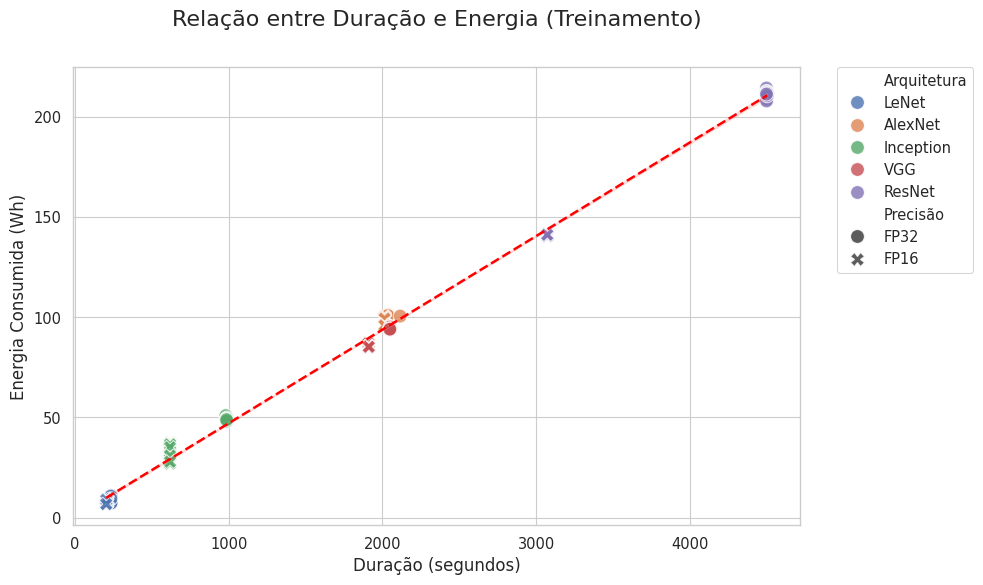

In [ ]:
# Scatter plot para visualizar a distribuição e relação linear
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_treino,
    x='duration',
    y='energy_consumed_wh',
    hue='Arquitetura',
    style='Precisão',
    s=100, # Tamanho dos pontos
    alpha=0.8 # Transparência
)

# Adicionar a reta de regressão (uma única para todo o dataset)
sns.regplot(
    data=df_treino,
    x='duration',
    y='energy_consumed_wh',
    scatter=False,  # Não desenhar pontos de dispersão duplicados
    color='red',    # Cor da linha de regressão
    line_kws={'linestyle': '--'} # Estilo da linha
)

plt.title('Relação entre Duração e Energia (Treinamento)', fontsize=16, pad=30)
plt.xlabel('Duração (segundos)', fontsize=12)
plt.ylabel('Energia Consumida (Wh)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

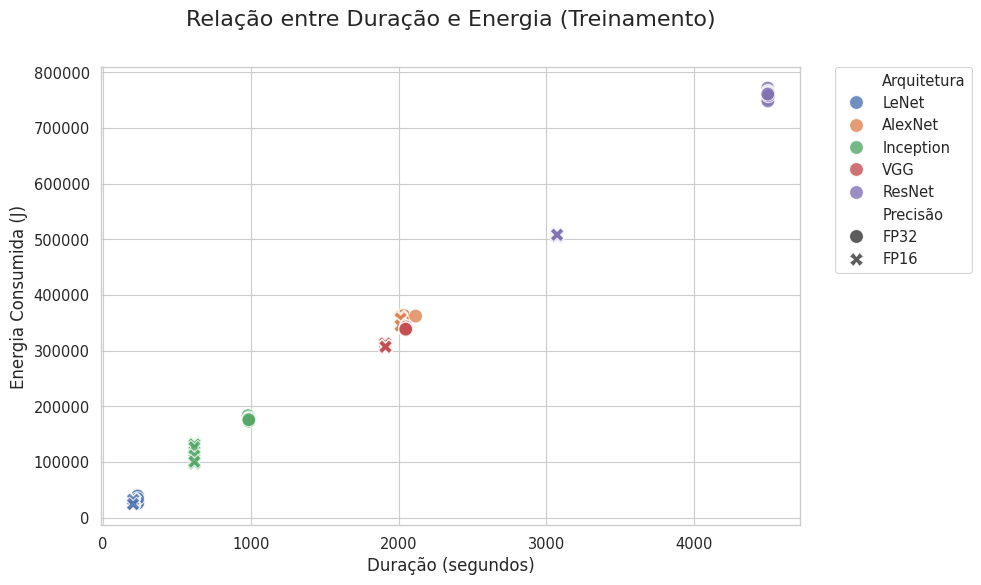

In [ ]:
# Scatter plot para visualizar a distribuição e relação linear
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_treino,
    x='duration',
    y='energy_consumed_joule',
    hue='Arquitetura',
    style='Precisão',
    s=100, # Tamanho dos pontos
    alpha=0.8 # Transparência
)

plt.title('Relação entre Duração e Energia (Treinamento)', fontsize=16, pad=30)
plt.xlabel('Duração (segundos)', fontsize=12)
plt.ylabel('Energia Consumida (J)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

### Observação 1

Como esperado, o tempo de execução e o consumo de energia são linearmente relacionados

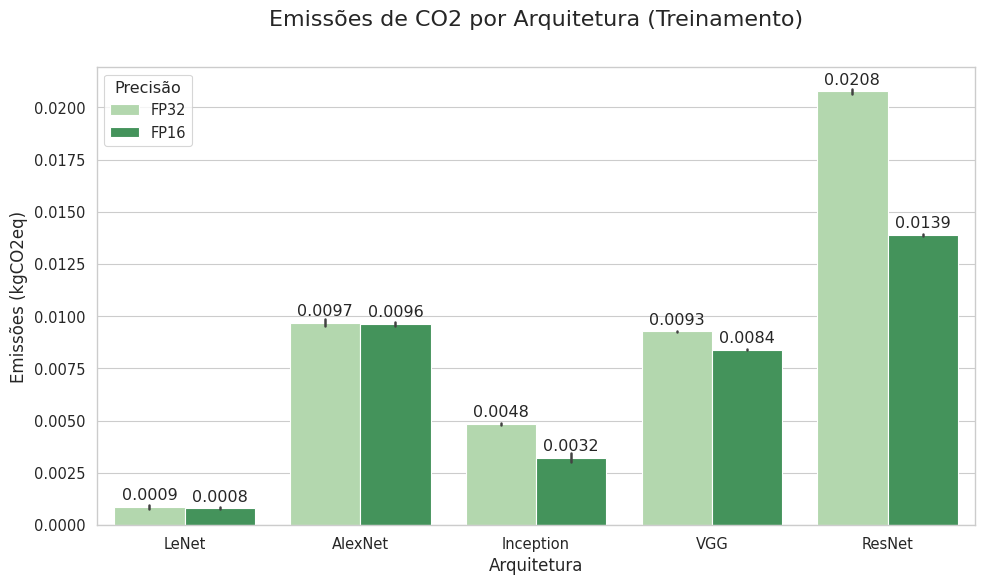

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_treino, x='Arquitetura', y='emissions', hue='Precisão', palette='Greens')

plt.title('Emissões de CO2 por Arquitetura (Treinamento)', fontsize=16, pad=30)
plt.ylabel('Emissões (kgCO2eq)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

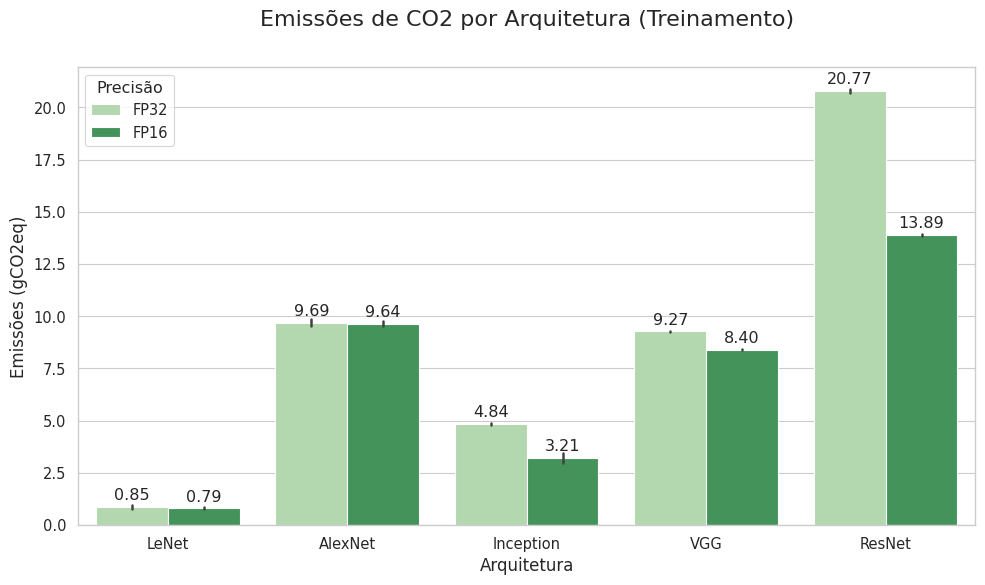

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_treino, x='Arquitetura', y='emissions_g', hue='Precisão', palette='Greens')

plt.title('Emissões de CO2 por Arquitetura (Treinamento)', fontsize=16, pad=30)
plt.ylabel('Emissões (gCO2eq)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

## Gráfico Inferência (teste)

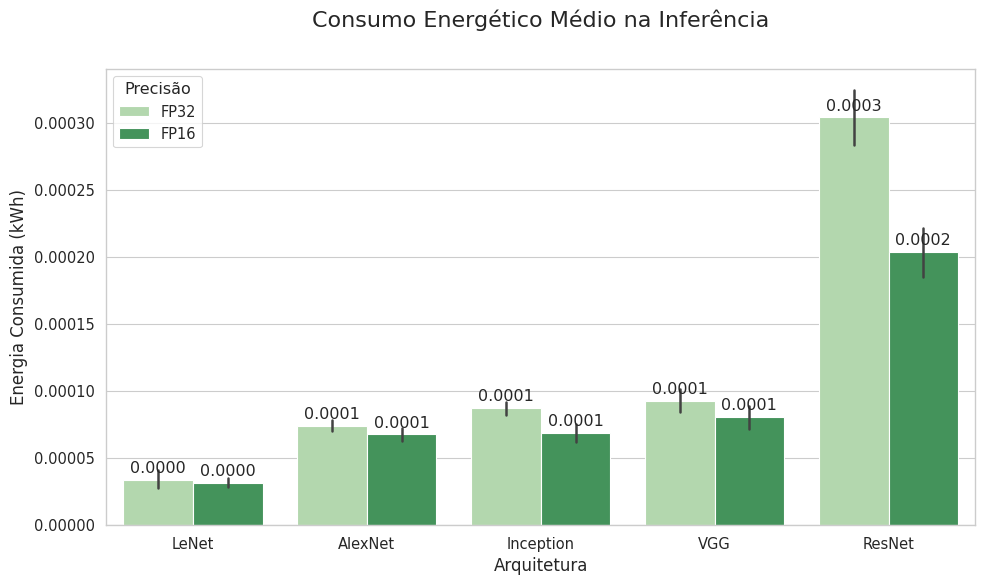

In [ ]:
# Gráfico de Barras: Energia por Arquitetura e Precisão
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_teste, x='Arquitetura', y='energy_consumed', hue='Precisão', palette='Greens')

plt.title('Consumo Energético Médio na Inferência', fontsize=16, pad=30)
plt.ylabel('Energia Consumida (kWh)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)
plt.legend(title='Precisão')

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

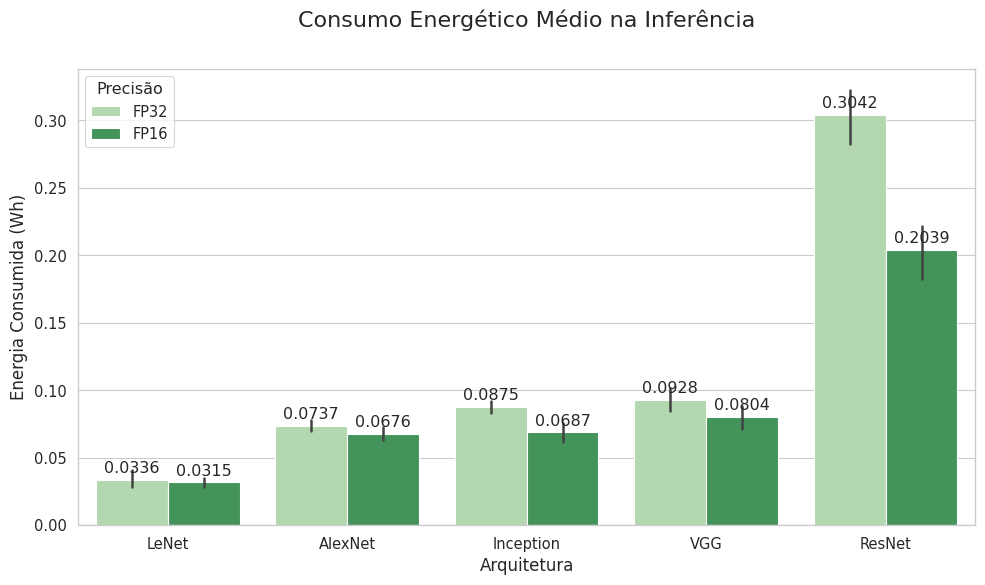

In [ ]:
# Gráfico de Barras: Energia por Arquitetura e Precisão
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_teste, x='Arquitetura', y='energy_consumed_wh', hue='Precisão', palette='Greens')

plt.title('Consumo Energético Médio na Inferência', fontsize=16, pad=30)
plt.ylabel('Energia Consumida (Wh)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)
plt.legend(title='Precisão')

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

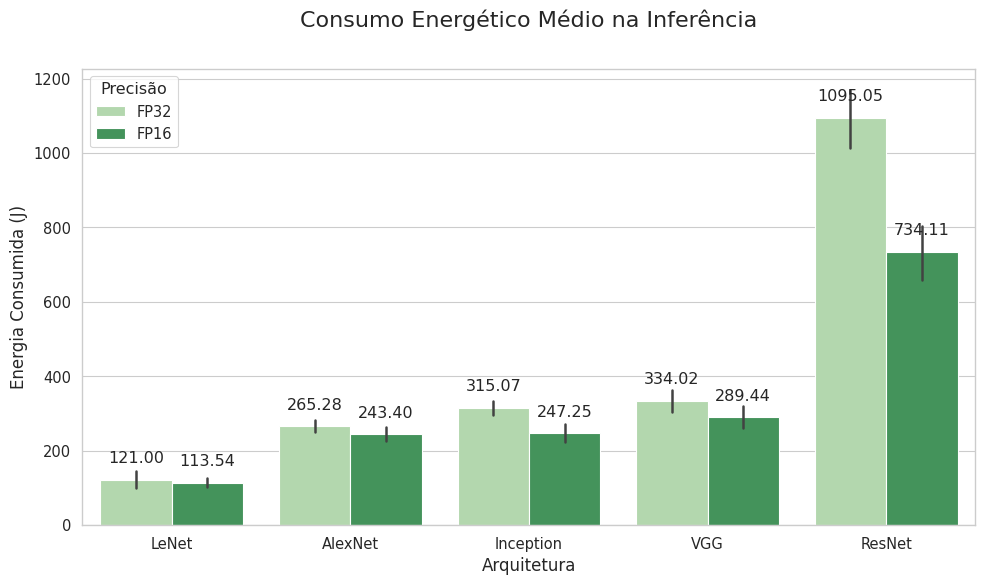

In [ ]:
# Gráfico de Barras: Energia por Arquitetura e Precisão
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_teste, x='Arquitetura', y='energy_consumed_joule', hue='Precisão', palette='Greens')

plt.title('Consumo Energético Médio na Inferência', fontsize=16, pad=30)
plt.ylabel('Energia Consumida (J)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)
plt.legend(title='Precisão')

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=10)

plt.tight_layout()
plt.show()

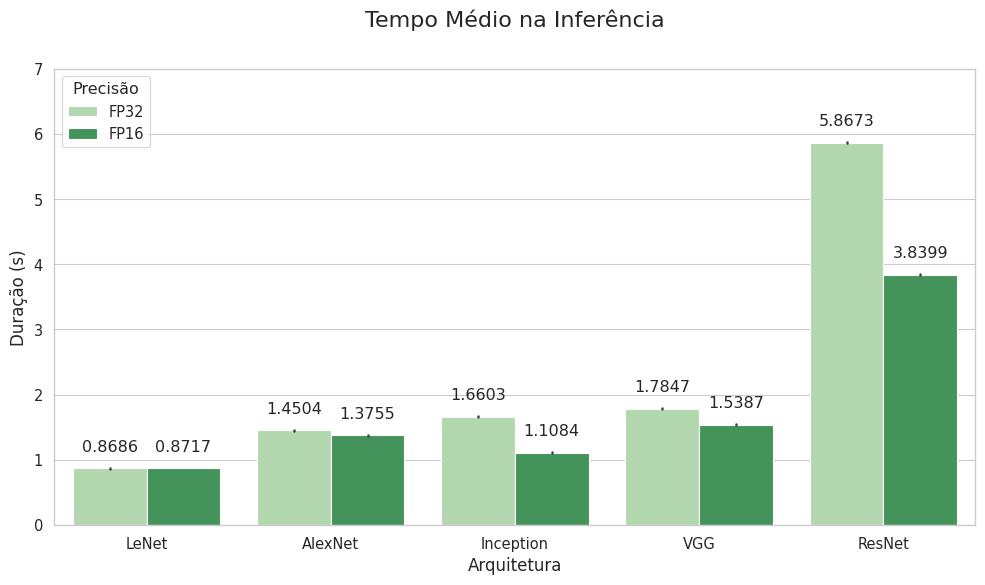

In [ ]:
# Gráfico de Barras: Energia por Arquitetura e Precisão
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_teste, x='Arquitetura', y='duration', hue='Precisão', palette='Greens')

plt.title('Tempo Médio na Inferência', fontsize=16, pad=30)
plt.ylabel('Duração (s)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)
plt.legend(title='Precisão')

plt.ylim(0, 7) # Ajuste de escala

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=10)

plt.tight_layout()
plt.show()

### Observação 2

Os valores são muito pequenos na inferência, devendo ser modificada a escala numérica

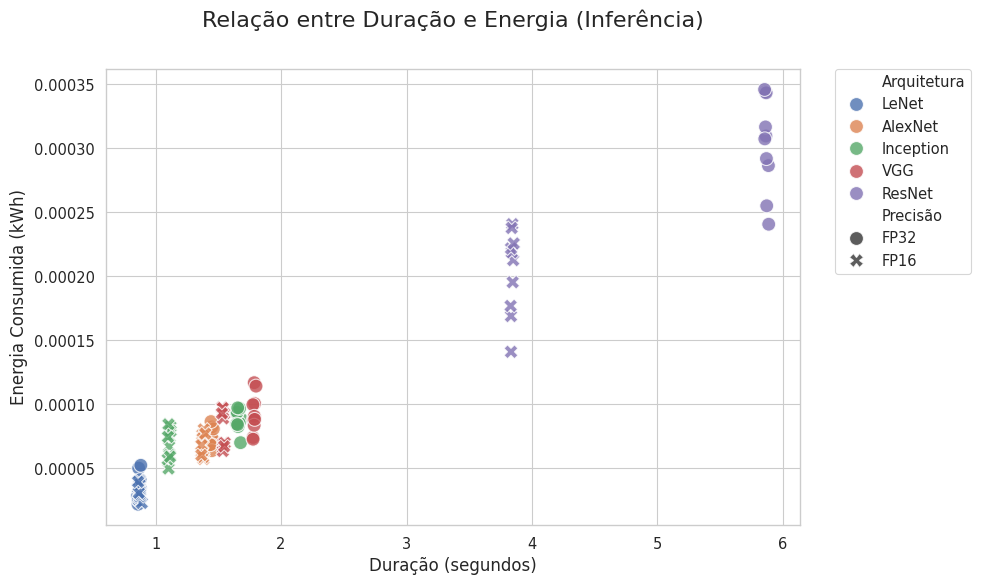

In [ ]:
# Scatter plot para visualizar a distribuição e relação linear
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_teste,
    x='duration',
    y='energy_consumed',
    hue='Arquitetura',
    style='Precisão',
    s=100, # Tamanho dos pontos
    alpha=0.8 # Transparência
)

plt.title('Relação entre Duração e Energia (Inferência)', fontsize=16, pad=30)
plt.xlabel('Duração (segundos)', fontsize=12)
plt.ylabel('Energia Consumida (kWh)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

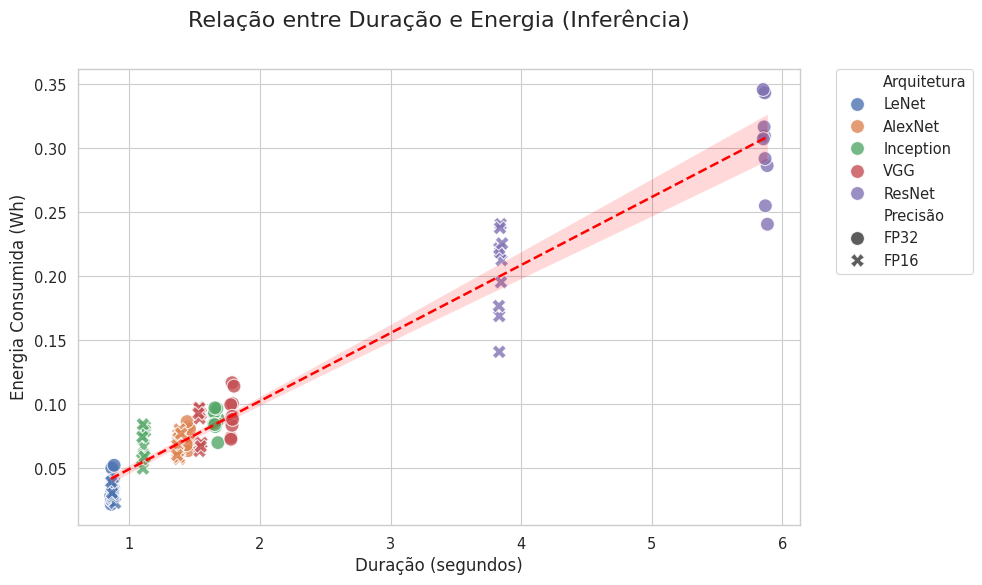

In [ ]:
# Scatter plot para visualizar a distribuição e relação linear
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_teste,
    x='duration',
    y='energy_consumed_wh',
    hue='Arquitetura',
    style='Precisão',
    s=100, # Tamanho dos pontos
    alpha=0.8 # Transparência
)

# Adicionar a reta de regressão (uma única para todo o dataset)
sns.regplot(
    data=df_teste,
    x='duration',
    y='energy_consumed_wh',
    scatter=False,  # Não desenhar pontos de dispersão duplicados
    color='red',    # Cor da linha de regressão
    line_kws={'linestyle': '--'} # Estilo da linha
)

plt.title('Relação entre Duração e Energia (Inferência)', fontsize=16, pad=30)
plt.xlabel('Duração (segundos)', fontsize=12)
plt.ylabel('Energia Consumida (Wh)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

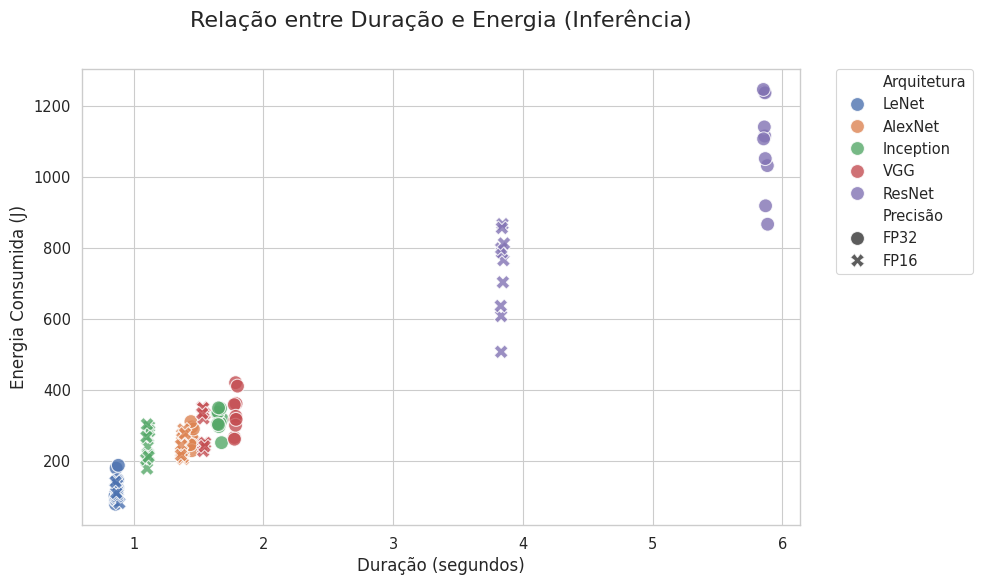

In [ ]:
# Scatter plot para visualizar a distribuição e relação linear
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_teste,
    x='duration',
    y='energy_consumed_joule',
    hue='Arquitetura',
    style='Precisão',
    s=100, # Tamanho dos pontos
    alpha=0.8, # Transparência
)

plt.title('Relação entre Duração e Energia (Inferência)', fontsize=16, pad=30)
plt.xlabel('Duração (segundos)', fontsize=12)
plt.ylabel('Energia Consumida (J)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

In [ ]:
# correlação linear entre consumo e tempo
correlacao_linear = df_teste[['duration', 'energy_consumed']].corr(method='pearson')
print(correlacao_linear)

                 duration  energy_consumed
duration         1.000000         0.974371
energy_consumed  0.974371         1.000000


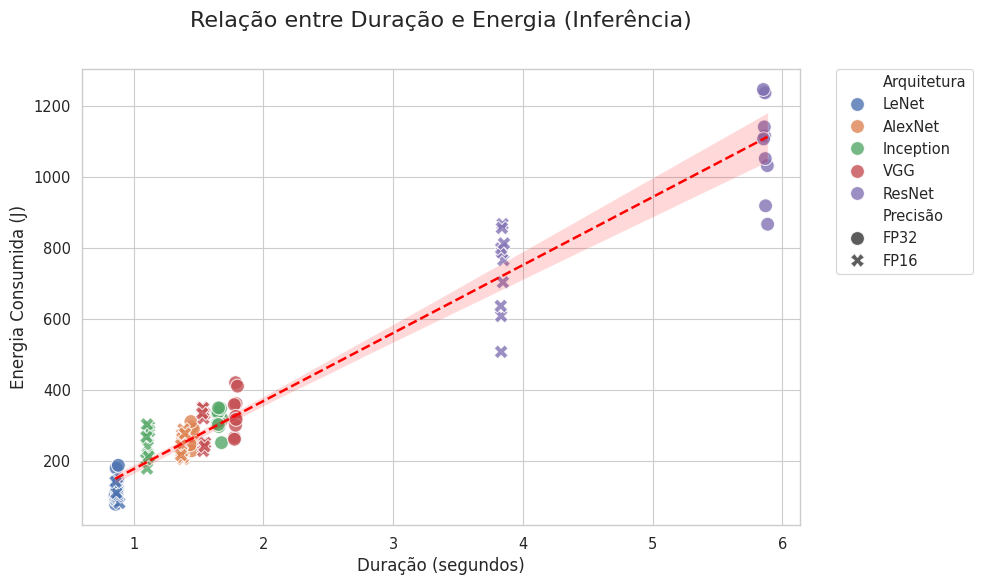

In [ ]:
# Scatter plot para visualizar a distribuição e relação linear
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_teste,
    x='duration',
    y='energy_consumed_joule',
    hue='Arquitetura',
    style='Precisão',
    s=100, # Tamanho dos pontos
    alpha=0.8 # Transparência
)

# Adicionar a reta de regressão (uma única para todo o dataset)
sns.regplot(
    data=df_teste,
    x='duration',
    y='energy_consumed_joule',
    scatter=False,  # Não desenhar pontos de dispersão duplicados
    color='red',    # Cor da linha de regressão
    line_kws={'linestyle': '--'} # Estilo da linha
)

plt.title('Relação entre Duração e Energia (Inferência)', fontsize=16, pad=30)
plt.xlabel('Duração (segundos)', fontsize=12)
plt.ylabel('Energia Consumida (J)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

### Observação 3

Como o consumo é pequeno, a variabilidade por observação é maior

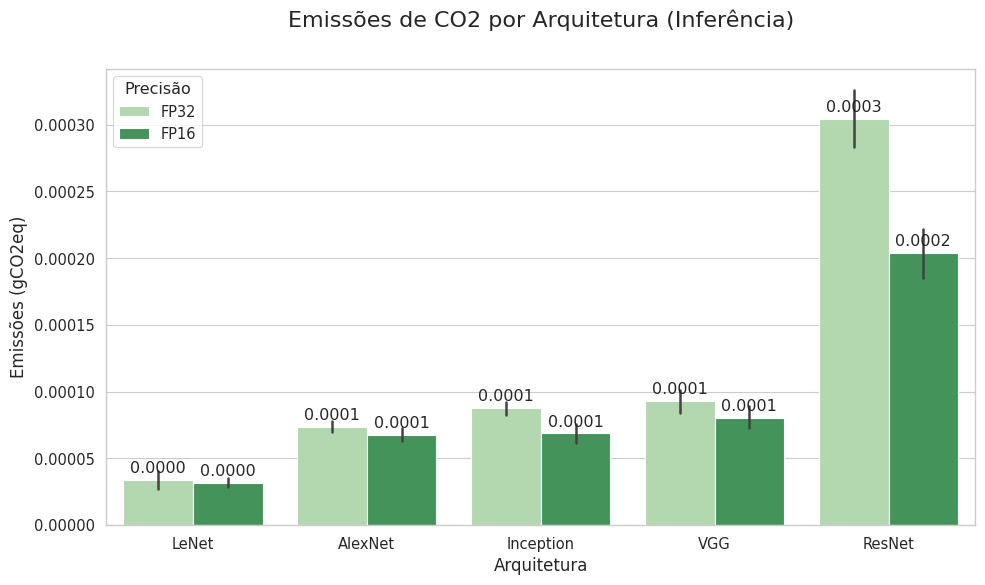

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_teste, x='Arquitetura', y='energy_consumed', hue='Precisão', palette='Greens')

plt.title('Emissões de CO2 por Arquitetura (Inferência)', fontsize=16, pad=30)
plt.ylabel('Emissões (gCO2eq)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

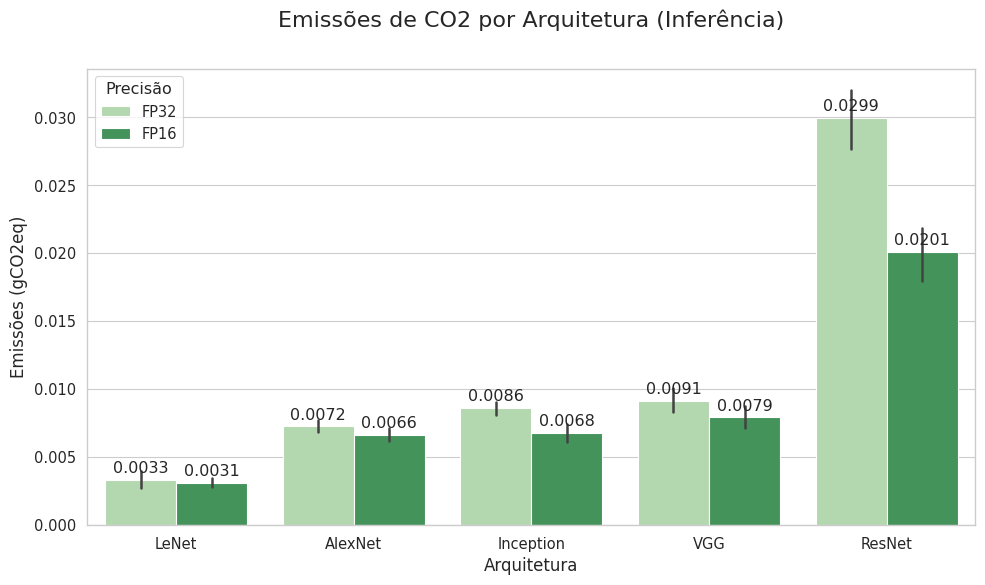

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_teste, x='Arquitetura', y='emissions_g', hue='Precisão', palette='Greens')

plt.title('Emissões de CO2 por Arquitetura (Inferência)', fontsize=16, pad=30)
plt.ylabel('Emissões (gCO2eq)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

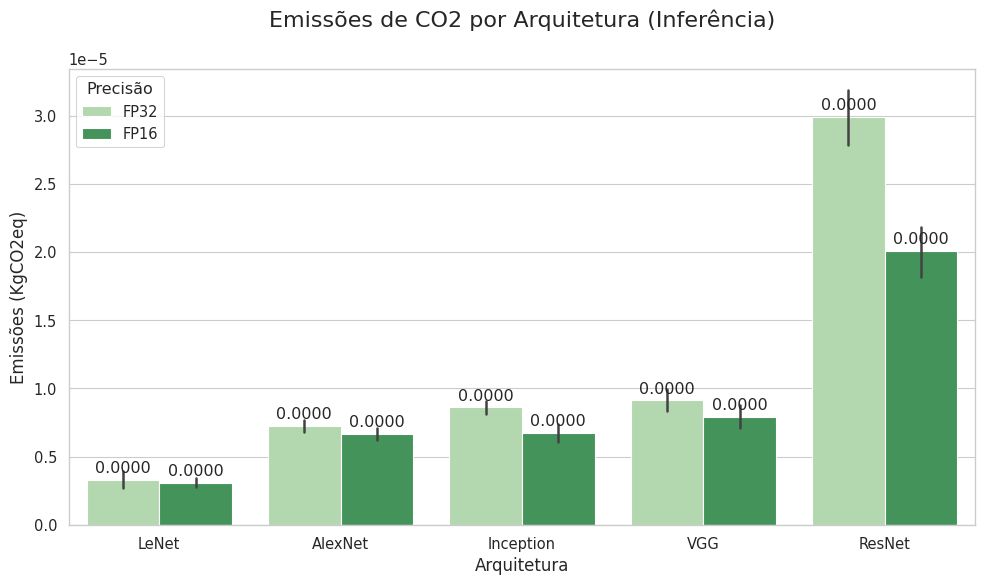

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_teste, x='Arquitetura', y='emissions', hue='Precisão', palette='Greens')

plt.title('Emissões de CO2 por Arquitetura (Inferência)', fontsize=16, pad=30)
plt.ylabel('Emissões (KgCO2eq)', fontsize=12)
plt.xlabel('Arquitetura', fontsize=12)

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

## Agregação dos dados

In [ ]:
df_treino.head()

,Arquitetura,Precisão,duration,emissions,energy_consumed,energy_consumed_joule,energy_consumed_wh,emissions_g
0,LeNet,FP32,204.543484,0.000743,0.007551,27184.8780,7.551355,0.742661
1,LeNet,FP32,234.942762,0.001084,0.011019,39667.1328,11.018648,1.083662
2,LeNet,FP32,232.213766,0.000711,0.007229,26023.4172,7.228727,0.710931
3,LeNet,FP32,233.011972,0.000782,0.007948,28611.1224,7.947534,0.781624
4,LeNet,FP32,232.581632,0.001016,0.010328,37179.3852,10.327607,1.015700


In [ ]:
df_treino.Arquitetura.unique()

array(['LeNet', 'AlexNet', 'Inception', 'VGG', 'ResNet'], dtype=object)

In [ ]:
colunas = ['duration', 'energy_consumed', 'emissions', 'energy_consumed_joule', 'emissions_g']

# Agregar dados de treinamento (médias)
treino_agg = df_treino.groupby(['Arquitetura', 'Precisão'])[colunas].mean().add_suffix('_treino')

# Agregar dados de inferência
teste_agg = df_teste.groupby(['Arquitetura', 'Precisão'])[colunas].mean().add_suffix('_teste')

# Agregar dados de resultados
resultado_agg = df_inferencia.groupby(['Arquitetura', 'Precisão'])[['Accuracy', 'Precision', 'Recall', 'F1 Score']].mean()

In [ ]:
#trocar o nome da arquitetura GoogLeNet por Inception
treino_agg.rename(index={'GoogLeNet': 'Inception'}, inplace=True)
teste_agg.rename(index={'GoogLeNet': 'Inception'}, inplace=True)
resultado_agg.rename(index={'GoogLeNet': 'Inception'}, inplace=True)

In [ ]:
# Unir os dataframes
df_final = treino_agg.join(teste_agg, how='inner')

In [ ]:

df_final = df_final.join(resultado_agg, how='inner')
df_final.reset_index(inplace=True)

# Exibir tabela consolidada
print("Tabela Consolidada (Médias):")
display(df_final)

Tabela Consolidada (Médias):


,Arquitetura,Precisão,duration_treino,energy_consumed_treino,emissions_treino,energy_consumed_joule_treino,emissions_g_treino,duration_teste,energy_consumed_teste,emissions_teste,energy_consumed_joule_teste,emissions_g_teste,Accuracy,Precision,Recall,F1 Score
0,AlexNet,FP16,2013.509371,0.098050,0.009643,352980.33480,9.643031,1.375519,0.000068,0.000007,243.3960,0.006649,0.83034,0.830533,0.83034,0.830354
1,AlexNet,FP32,2044.933401,0.098512,0.009688,354642.43104,9.688437,1.450376,0.000074,0.000007,265.2840,0.007245,0.82856,0.829362,0.82856,0.828841
2,Inception,FP16,618.150005,0.032667,0.003213,117600.22044,3.212707,1.108399,0.000069,0.000007,247.2480,0.006754,0.84267,0.842443,0.84267,0.842469
3,Inception,FP32,986.538784,0.049209,0.004840,177150.95352,4.839567,1.660287,0.000088,0.000009,315.0720,0.008609,0.84235,0.842058,0.84235,0.842121
4,LeNet,FP16,206.331515,0.008074,0.000794,29067.17832,0.794083,0.871730,0.000032,0.000003,113.5440,0.003101,0.73721,0.737372,0.73721,0.737088
5,LeNet,FP32,231.074199,0.008656,0.000851,31159.81800,0.851252,0.868629,0.000034,0.000003,120.9960,0.003306,0.73031,0.730519,0.73031,0.730140
6,ResNet,FP16,3071.502118,0.141218,0.013889,508384.59048,13.888502,3.839927,0.000204,0.000020,734.1084,0.020060,0.86341,0.863883,0.86341,0.863549
7,ResNet,FP32,4499.224606,0.211230,0.020774,760428.74988,20.774069,5.867331,0.000304,0.000030,1095.0480,0.029920,0.87065,0.870444,0.87065,0.870436
8,VGG,FP16,1911.054634,0.085403,0.008399,307452.09672,8.399250,1.538737,0.000080,0.000008,289.4400,0.007908,0.86167,0.861864,0.86167,0.861697
9,VGG,FP32,2048.862586,0.094234,0.009268,339241.95720,9.267713,1.784686,0.000093,0.000009,334.0224,0.009126,0.86035,0.860703,0.86035,0.860429


### Performance

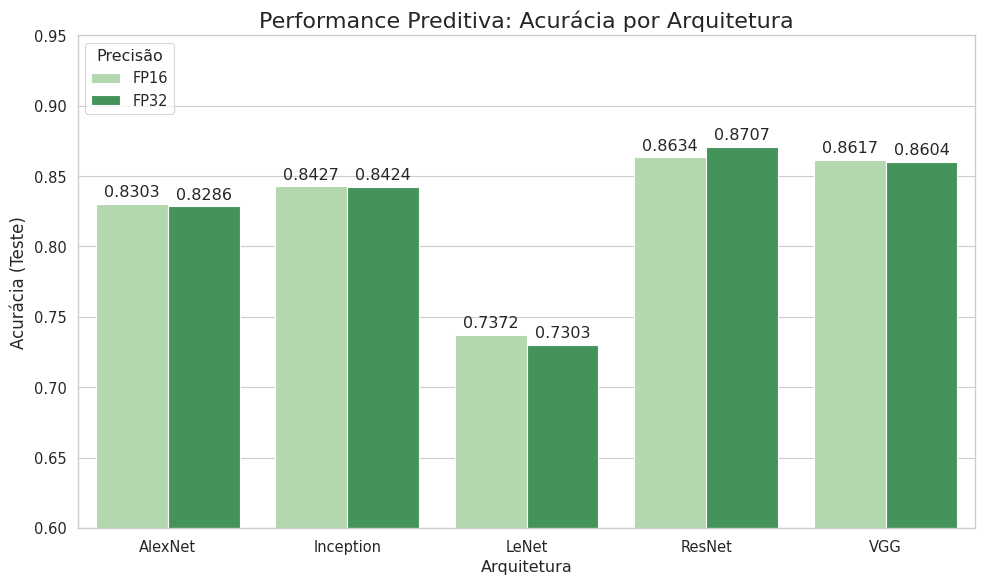

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_final, x='Arquitetura', y='Accuracy', hue='Precisão', palette='Greens')

plt.title('Performance Preditiva: Acurácia por Arquitetura', fontsize=16)
plt.ylabel('Acurácia (Teste)', fontsize=12)
plt.ylim(0.6, 0.95) # Ajuste de escala
plt.legend(loc='upper left', title='Precisão')

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

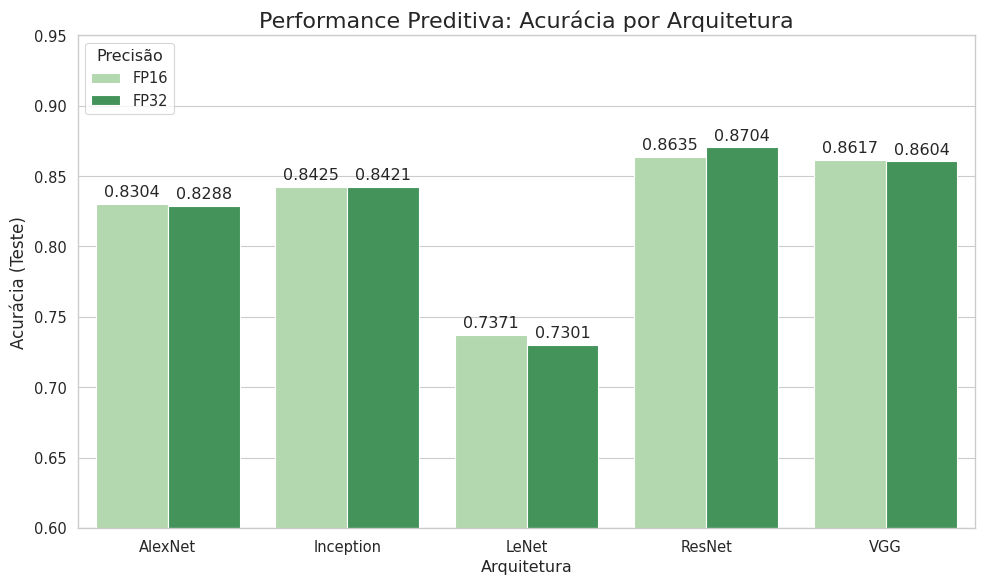

In [ ]:
plt.figure(figsize=(10, 6))
# Focando no eixo Y entre 0.6 e 0.9 para destacar diferenças
ax = sns.barplot(data=df_final, x='Arquitetura', y='F1 Score', hue='Precisão', palette='Greens')

plt.title('Performance Preditiva: Acurácia por Arquitetura', fontsize=16)
plt.ylabel('Acurácia (Teste)', fontsize=12)
plt.ylim(0.6, 0.95) # Ajuste de escala
plt.legend(loc='upper left', title='Precisão')

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

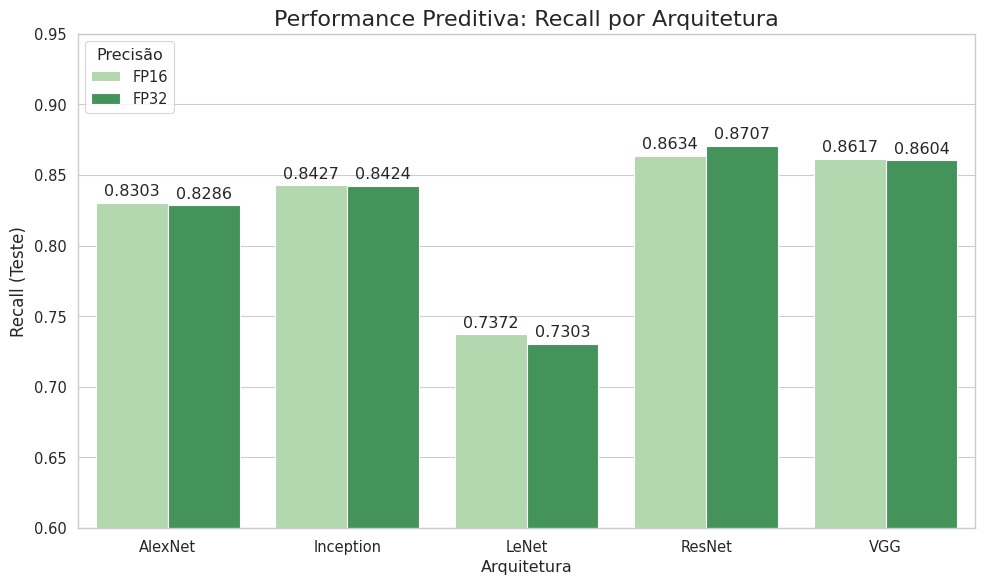

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_final, x='Arquitetura', y='Recall', hue='Precisão', palette='Greens')

plt.title('Performance Preditiva: Recall por Arquitetura', fontsize=16)
plt.ylabel('Recall (Teste)', fontsize=12)
plt.ylim(0.6, 0.95) # Ajuste de escala
plt.legend(loc='upper left', title='Precisão')

# Adicionando valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
# fig.suptitle('Métricas de Inferência por Precisão Numérica', fontsize=16)
# axes = axes.flatten()

# columns_to_plot = ["Acurácia Teste", "Precisão Teste", "Recall Teste", "F1 Score Teste"]
# nomes_colunas = ["Acurácia", "Precisão", "Revocação", "Medida F1"]

# for i, col in enumerate(columns_to_plot):
#     sns.barplot(x='Arquitetura', y=col, data=df_inferencia, hue='Precisão', ax=axes[i], palette='Greens', alpha=0.8)
#     axes[i].set_title(nomes_colunas[i])
#     axes[i].set_xlabel('Arquitetura')
#     axes[i].set_ylabel(col)
#     if i == 1:
#         axes[i].legend(title='Precisão Numérica', loc='upper left', bbox_to_anchor=(1, 1))
#     else:
#         axes[i].legend().remove()

# # Hide the unused subplots
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()

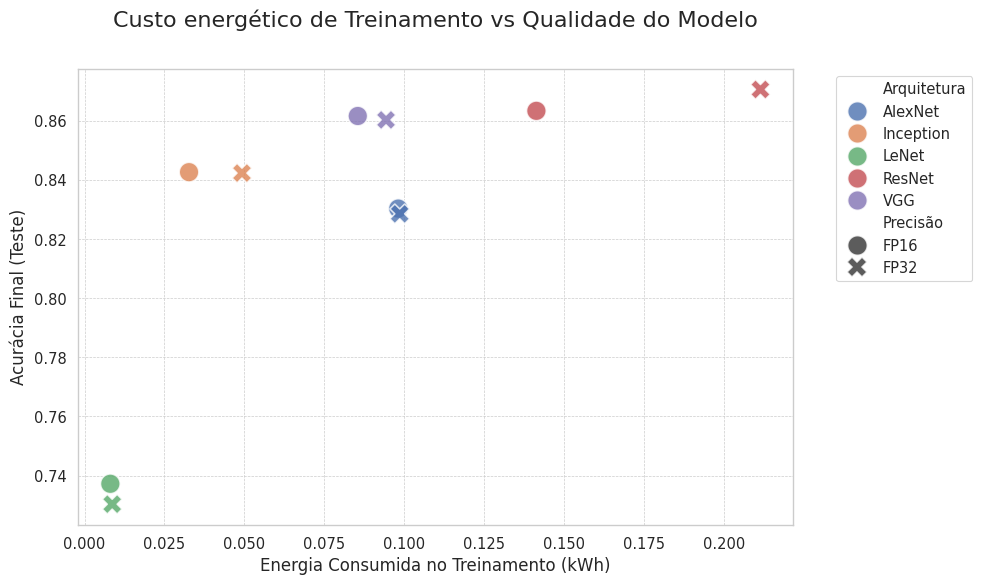

In [ ]:
# Este gráfico mostra o "custo" energético para se obter determinada acurácia
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_final,
    x='energy_consumed_treino',
    y='Accuracy',
    hue='Arquitetura',
    style='Precisão',
    s=200, # Tamanho dos pontos
    alpha=0.8
)

plt.title('Custo energético de Treinamento vs Qualidade do Modelo', fontsize=16, pad=30)
plt.xlabel('Energia Consumida no Treinamento (kWh)', fontsize=12)
plt.ylabel('Acurácia Final (Teste)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

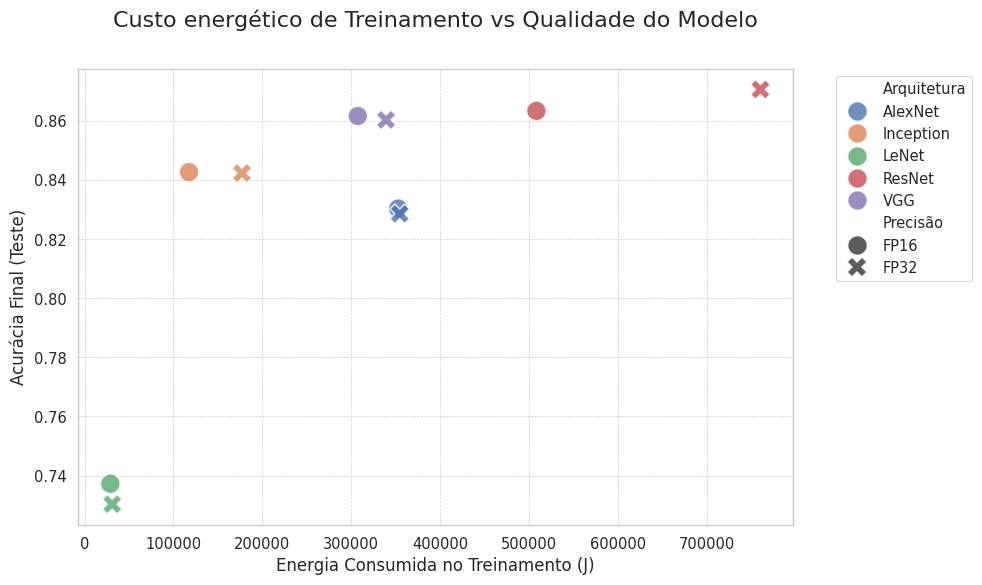

In [ ]:
# Este gráfico mostra o "custo" energético para se obter determinada acurácia
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_final,
    x='energy_consumed_joule_treino',
    y='Accuracy',
    hue='Arquitetura',
    style='Precisão',
    s=200, # Tamanho dos pontos
    alpha=0.8
)

plt.title('Custo energético de Treinamento vs Qualidade do Modelo', fontsize=16, pad=30)
plt.xlabel('Energia Consumida no Treinamento (J)', fontsize=12)
plt.ylabel('Acurácia Final (Teste)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

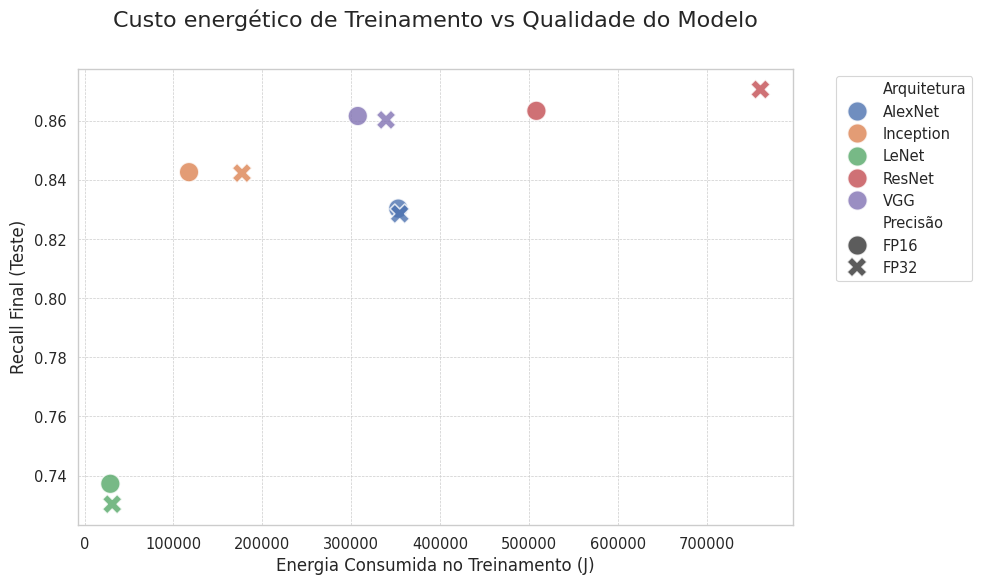

In [ ]:
# Este gráfico mostra o "custo" energético para se obter determinada acurácia
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_final,
    x='energy_consumed_joule_treino',
    y='Recall',
    hue='Arquitetura',
    style='Precisão',
    s=200, # Tamanho dos pontos
    alpha=0.8
)

plt.title('Custo energético de Treinamento vs Qualidade do Modelo', fontsize=16, pad=30)
plt.xlabel('Energia Consumida no Treinamento (J)', fontsize=12)
plt.ylabel('Recall Final (Teste)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

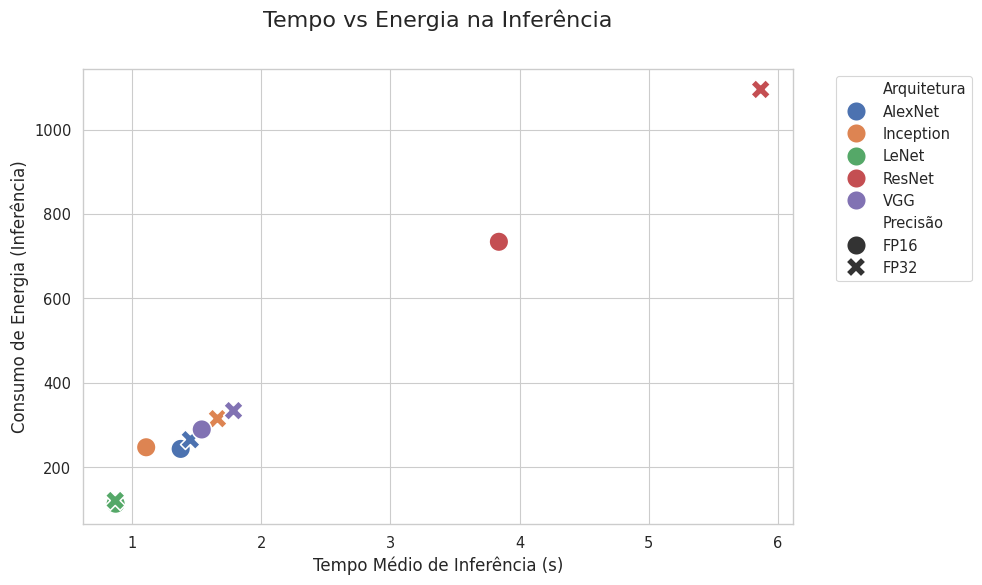

In [ ]:
# Analisando o custo operacional (inferência)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_final,
    x='duration_teste',
    y='energy_consumed_joule_teste',
    hue='Arquitetura',
    style='Precisão',
    s=200,
    palette='deep'
)

plt.title('Tempo vs Energia na Inferência', fontsize=16, pad=30)
plt.xlabel('Tempo Médio de Inferência (s)', fontsize=12)
plt.ylabel('Consumo de Energia (Inferência)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Análise exploratória

In [ ]:
df_final_pivotada = df_final.pivot(index='Arquitetura', columns='Precisão')
df_final_pivotada

duration_treino              energy_consumed_treino            \
Precisão               FP16         FP32                   FP16      FP32   
Arquitetura                                                                 
AlexNet         2013.509371  2044.933401               0.098050  0.098512   
Inception        618.150005   986.538784               0.032667  0.049209   
LeNet            206.331515   231.074199               0.008074  0.008656   
ResNet          3071.502118  4499.224606               0.141218  0.211230   
VGG             1911.054634  2048.862586               0.085403  0.094234   

            emissions_treino           energy_consumed_joule_treino  \
Precisão                FP16      FP32                         FP16   
Arquitetura                                                           
AlexNet             0.009643  0.009688                 352980.33480   
Inception           0.003213  0.004840                 117600.22044   
LeNet               0.000794  0.000851                  29067.17832   
ResNet              0.013889  0.020774                 508384.59048   
VGG                 0.008399  0.009268                 307452.09672   

                          emissions_g_treino             ...  \
Precisão             FP32               FP16       FP32  ...   
Arquitetura                                              ...   
AlexNet      354642.43104           9.643031   9.688437  ...   
Inception    177150.95352           3.212707   4.839567  ...   
LeNet         31159.81800           0.794083   0.851252  ...   
ResNet       760428.74988          13.888502  20.774069  ...   
VGG          339241.95720           8.399250   9.267713  ...   

            emissions_g_teste           Accuracy          Precision            \
Precisão                 FP16      FP32     FP16     FP32      FP16      FP32   
Arquitetura                                                                     
AlexNet              0.006649  0.007245  0.83034  0.82856  0.830533  0.829362   
Inception            0.006754  0.008609  0.84267  0.84235  0.842443  0.842058   
LeNet                0.003101  0.003306  0.73721  0.73031  0.737372  0.730519   
ResNet               0.020060  0.029920  0.86341  0.87065  0.863883  0.870444   
VGG                  0.007908  0.009126  0.86167  0.86035  0.861864  0.860703   

              Recall           F1 Score            
Precisão        FP16     FP32      FP16      FP32  
Arquitetura                                        
AlexNet      0.83034  0.82856  0.830354  0.828841  
Inception    0.84267  0.84235  0.842469  0.842121  
LeNet        0.73721  0.73031  0.737088  0.730140  
ResNet       0.86341  0.87065  0.863549  0.870436  
VGG          0.86167  0.86035  0.861697  0.860429  

[5 rows x 28 columns]

In [ ]:
# cálculo das diferenças proporcionais entre as métricas, comparando fp 32 e fp 16

resultado_diferencas = pd.DataFrame(index=df_final_pivotada.index)

resultado_diferencas["Δ Tempo Treino"] = (
    df_final_pivotada[("duration_treino", "FP16")] -
    df_final_pivotada[("duration_treino", "FP32")]
) / df_final_pivotada[("duration_treino", "FP32")]

resultado_diferencas["Δ Energia Treino"] = (
    df_final_pivotada[("energy_consumed_treino", "FP16")] -
    df_final_pivotada[("energy_consumed_treino", "FP32")]
) / df_final_pivotada[("energy_consumed_treino", "FP32")]

# resultado_diferencas["Δ Energia (J) Treino"] = (
#     df_final_pivotada[("energy_consumed_joule_treino", "FP16")] -
#     df_final_pivotada[("energy_consumed_joule_treino", "FP32")]
# ) / df_final_pivotada[("energy_consumed_joule_treino", "FP32")]

resultado_diferencas["Δ Tempo Teste"] = (
    df_final_pivotada[("duration_teste", "FP16")] -
    df_final_pivotada[("duration_teste", "FP32")]
) / df_final_pivotada[("duration_teste", "FP32")]

resultado_diferencas["Δ Energia Teste"] = (
    df_final_pivotada[("energy_consumed_teste", "FP16")] -
    df_final_pivotada[("energy_consumed_teste", "FP32")]
) / df_final_pivotada[("energy_consumed_teste", "FP32")]

# resultado_diferencas["Δ Energia (J) Teste"] = (
#     df_final_pivotada[("energy_consumed_joule_teste", "FP16")] -
#     df_final_pivotada[("energy_consumed_joule_teste", "FP32")]
# ) / df_final_pivotada[("energy_consumed_joule_teste", "FP32")]

resultado_diferencas["Δ Accuracy"] = (
    df_final_pivotada[("Accuracy", "FP16")] -
    df_final_pivotada[("Accuracy", "FP32")]
) / df_final_pivotada[("Accuracy", "FP32")]

resultado_diferencas["Δ Precision"] = (
    df_final_pivotada[("Precision", "FP16")] -
    df_final_pivotada[("Precision", "FP32")]
) / df_final_pivotada[("Precision", "FP32")]

resultado_diferencas["Δ Recall"] = (
    df_final_pivotada[("Recall", "FP16")] -
    df_final_pivotada[("Recall", "FP32")]
) / df_final_pivotada[("Recall", "FP32")]

resultado_diferencas["Δ F1 Score"] = (
    df_final_pivotada[("F1 Score", "FP16")] -
    df_final_pivotada[("F1 Score", "FP32")]
) / df_final_pivotada[("F1 Score", "FP32")]

resultado_diferencas = resultado_diferencas.reset_index()
resultado_diferencas

,Arquitetura,Δ Tempo Treino,Δ Energia Treino,Δ Tempo Teste,Δ Energia Teste,Δ Accuracy,Δ Precision,Δ Recall,Δ F1 Score
0,AlexNet,-0.015367,-0.004687,-0.051612,-0.082508,0.002148,0.001412,0.002148,0.001825
1,Inception,-0.373415,-0.336158,-0.332405,-0.215265,0.000380,0.000457,0.000380,0.000413
2,LeNet,-0.107077,-0.067158,0.003569,-0.061589,0.009448,0.009380,0.009448,0.009515
3,ResNet,-0.317326,-0.331450,-0.345541,-0.329611,-0.008316,-0.007537,-0.008316,-0.007913
4,VGG,-0.067261,-0.093709,-0.137811,-0.133471,0.001534,0.001348,0.001534,0.001474


In [ ]:
resultado_diferencas.to_excel('resultado_diferencas.xlsx')

In [ ]:
df_final_pivotada[[
    ("duration_teste", "FP16"),
    ("duration_teste", "FP32"),
    ("duration_treino", "FP16"),
    ("duration_treino", "FP32"),
    ('Accuracy', "FP16"),
    ('Accuracy', "FP32"),
    ('Precision', "FP16"),
    ('Precision', "FP32"),
    ('Recall', "FP16"),
    ('Recall', "FP32"),
    ('F1 Score', "FP16"),
    ('F1 Score', "FP32")
]].to_excel('df_final_pivotada.xlsx')

### Observação 4


As diferenças proporcionais foram calculadas comparando-se os valores médios obtidos em FP16 em relação a FP32, utilizando a razão:

(𝐹𝑃16−𝐹𝑃32)/𝐹𝑃32

Valores negativos indicam redução de custo computacional (tempo ou energia), enquanto valores positivos indicam ganho relativo em métricas de desempenho.

In [ ]:
resultado_diferencas["Δ% Tempo Treino"] = resultado_diferencas["Δ Tempo Treino"] *100
resultado_diferencas["Δ% Energia Treino"] = resultado_diferencas["Δ Energia Treino"] *100
resultado_diferencas["Δ% Tempo Teste"] = resultado_diferencas["Δ Tempo Teste"] *100
resultado_diferencas["Δ% Energia Teste"] = resultado_diferencas["Δ Energia Teste"] *100
resultado_diferencas["Δ% Accuracy"] = resultado_diferencas["Δ Accuracy"] *100
resultado_diferencas["Δ% Precision"] = resultado_diferencas["Δ Precision"] *100
resultado_diferencas["Δ% Recall"] = resultado_diferencas["Δ Recall"] *100
resultado_diferencas["Δ% F1 Score"] = resultado_diferencas["Δ F1 Score"] *100

resultado_diferencas

,Arquitetura,Δ Tempo Treino,Δ Energia Treino,Δ Tempo Teste,Δ Energia Teste,Δ Accuracy,Δ Precision,Δ Recall,Δ F1 Score,Δ% Tempo Treino,Δ% Energia Treino,Δ% Tempo Teste,Δ% Energia Teste,Δ% Accuracy,Δ% Precision,Δ% Recall,Δ% F1 Score
0,AlexNet,-0.015367,-0.004687,-0.051612,-0.082508,0.002148,0.001412,0.002148,0.001825,-1.536677,-0.468668,-5.161181,-8.250780,0.214831,0.141151,0.214831,0.182509
1,Inception,-0.373415,-0.336158,-0.332405,-0.215265,0.000380,0.000457,0.000380,0.000413,-37.341540,-33.615813,-33.240531,-21.526508,0.037989,0.045688,0.037989,0.041349
2,LeNet,-0.107077,-0.067158,0.003569,-0.061589,0.009448,0.009380,0.009448,0.009515,-10.707679,-6.715828,0.356899,-6.158881,0.944804,0.938014,0.944804,0.951524
3,ResNet,-0.317326,-0.331450,-0.345541,-0.329611,-0.008316,-0.007537,-0.008316,-0.007913,-31.732634,-33.145007,-34.554117,-32.961076,-0.831563,-0.753692,-0.831563,-0.791252
4,VGG,-0.067261,-0.093709,-0.137811,-0.133471,0.001534,0.001348,0.001534,0.001474,-6.726071,-9.370852,-13.781120,-13.347129,0.153426,0.134800,0.153426,0.147417


### Observação 5

Podemos observar que o ganho de desempenho médio no treino dos modelos (tempo e energia) foi maior nos modos "mais modernos".


O ganho de desempenho no teste também foi maior nos modelos mais modernos (googleNet e ResNet).


Enquanto a mudança nos resultados não chegou a 1%

## Testes estatísticos

### Testes comparativos individuais

In [ ]:
# significância
ALPHA = 0.05

metricas_eficiencia = [
    'duration', 'energy_consumed', 'emissions',
]

metricas_desempenho = [
    'Accuracy', 'Precision', 'Recall', 'F1 Score'
]


# def resultado_significativo(p):
#     return "SIM" if p < ALPHA else "NÃO"

def interpretar_shapiro(p, alpha=ALPHA):
    if pd.isna(p):
        return "Não avaliado"
    return "Normal" if p >= alpha else "Não normal"

def interpretar_levene(p, alpha=ALPHA):
    if pd.isna(p):
        return "Não avaliado"
    return "Variâncias homogêneas" if p >= alpha else "Variâncias heterogêneas"

def interpretar_teste_principal(p, alpha=ALPHA):
    if pd.isna(p):
        return "Não avaliado"
    return "Diferença significativa" if p < alpha else "Sem diferença significativa"

In [ ]:
# teste de nromalidade Shapiro-Wilk
def teste_shapiro_por_grupo(df, fase, metricas_numericas):
    resultados = []

    for arquitetura in df['Arquitetura'].unique():
        for metrica in metricas_numericas:

            grupo_fp32 = df[(df['Arquitetura'] == arquitetura) & (df['Precisão'] == 'FP32')][metrica].dropna()

            grupo_fp16 = df[(df['Arquitetura'] == arquitetura) & (df['Precisão'] == 'FP16')][metrica].dropna()

            if len(grupo_fp32) >= 3:
                _, p_fp32 = stats.shapiro(grupo_fp32)
                resultados.append([fase, arquitetura, "Shapiro-Wilk", metrica, "FP32", p_fp32, interpretar_shapiro(p_fp32)])

            if len(grupo_fp16) >= 3:
                _, p_fp16 = stats.shapiro(grupo_fp16)
                resultados.append([fase, arquitetura, "Shapiro-Wilk", metrica, "FP16", p_fp16, interpretar_shapiro(p_fp16)])

    return resultados

In [ ]:
# teste de homgenidade
def teste_levene(df, fase, metricas_numericas):
    resultados = []

    for arquitetura in df['Arquitetura'].unique():
        for metrica in metricas_numericas:

            grupo_fp32 = df[(df['Arquitetura'] == arquitetura) & (df['Precisão'] == 'FP32')][metrica].dropna()

            grupo_fp16 = df[(df['Arquitetura'] == arquitetura) & (df['Precisão'] == 'FP16')][metrica].dropna()

            if len(grupo_fp32) >= 2 and len(grupo_fp16) >= 2:
                _, p_levene = stats.levene(grupo_fp32, grupo_fp16)
                resultados.append([fase, arquitetura, "Levene", metrica, "FP32/FP16", p_levene, interpretar_levene(p_levene)])

    return resultados

In [ ]:
resultados = []

# Treinamento
resultados.extend(teste_shapiro_por_grupo(df_treino, 'Treinamento', metricas_eficiencia))
resultados.extend(teste_levene(df_treino, 'Treinamento', metricas_eficiencia))

# Teste
resultados.extend(teste_shapiro_por_grupo(df_teste, 'Teste', metricas_eficiencia))
resultados.extend(teste_levene(df_teste, 'Teste', metricas_eficiencia))

# resultado Inferência
resultados.extend(teste_shapiro_por_grupo(df_inferencia, 'Inferência', metricas_desempenho))
resultados.extend(teste_levene(df_inferencia, 'Inferência', metricas_desempenho))

# DataFrame final
df_resultados = pd.DataFrame(
    resultados,
    columns=['Fase', 'Arquitetura', 'Teste', 'Variável', 'Precisão', 'p-valor', 'Significativo']
)

df_resultados

,Fase,Arquitetura,Teste,Variável,Precisão,p-valor,Significativo
0,Treinamento,LeNet,Shapiro-Wilk,duration,FP32,0.000002,Não normal
1,Treinamento,LeNet,Shapiro-Wilk,duration,FP16,0.009750,Não normal
2,Treinamento,LeNet,Shapiro-Wilk,energy_consumed,FP32,0.014823,Não normal
3,Treinamento,LeNet,Shapiro-Wilk,energy_consumed,FP16,0.493003,Normal
4,Treinamento,LeNet,Shapiro-Wilk,emissions,FP32,0.014823,Não normal
...,...,...,...,...,...,...,...
145,Inferência,VGG,Levene,F1 Score,FP32/FP16,0.995960,Variâncias homogêneas
146,Inferência,ResNet,Levene,Accuracy,FP32/FP16,0.585816,Variâncias homogêneas
147,Inferência,ResNet,Levene,Precision,FP32/FP16,0.703858,Variâncias homogêneas
148,Inferência,ResNet,Levene,Recall,FP32/FP16,0.585816,Variâncias homogêneas


In [ ]:
df_resultados.to_excel('df_resultados.xlsx', index=False)

### Observação 6

Com os testes de normalidade e de homogeneidade, podemos escolher o teste adequado:
1. se distribuições normais e homogêneo -> teste student
2. se distribuições normais e não homogêneo -> teste de Welch
3. se uma das distribuições não for normal -> teste Mann–Whitney

In [ ]:
def decidir_teste(shapiro_fp32, shapiro_fp16, levene_p):
    """
    Recebe p-valores dos testes prévios
    Retorna o nome do teste estatístico a ser aplicado
    """

    normal_fp32 = shapiro_fp32 >= ALPHA
    normal_fp16 = shapiro_fp16 >= ALPHA
    homocedastico = levene_p >= ALPHA

    if normal_fp32 and normal_fp16:
        if homocedastico:
            return 't-test Student'
        else:
            return 't-test Welch'
    else:
        return 'Mann-Whitney U'

In [ ]:
def teste_comparativo(df, fase, metricas_numericas):
    resultados = []

    for arquitetura in df['Arquitetura'].unique():
        for variavel in metricas_numericas:

            fp32 = df[(df['Arquitetura'] == arquitetura) & (df['Precisão'] == 'FP32')][variavel].dropna()

            fp16 = df[(df['Arquitetura'] == arquitetura) & (df['Precisão'] == 'FP16')][variavel].dropna()

            if len(fp32) < 2 or len(fp16) < 2:
                continue

            # Testes prévios
            shapiro_fp32_p = stats.shapiro(fp32)[1] if len(fp32) >= 3 else 0
            shapiro_fp16_p = stats.shapiro(fp16)[1] if len(fp16) >= 3 else 0
            levene_p = stats.levene(fp32, fp16)[1]

            # Decisão automática
            teste = decidir_teste(shapiro_fp32_p, shapiro_fp16_p, levene_p)

            # Teste principal
            if teste == 't-test Student':
                _, p_valor = stats.ttest_ind(fp32, fp16, equal_var=True)

            elif teste == 't-test Welch':
                _, p_valor = stats.ttest_ind(fp32, fp16, equal_var=False)

            else:  # Mann-Whitney
                _, p_valor = stats.mannwhitneyu(fp32, fp16, alternative='two-sided')

            significante = interpretar_teste_principal(p_valor)
            # significante = "SIM" if p_valor < ALPHA else "NÃO"

            resultados.append([fase, arquitetura, teste, variavel, p_valor, significante])

    return resultados


In [ ]:
resultados_finais = []

resultados_finais.extend(teste_comparativo(df_treino, 'Treinamento', metricas_eficiencia))
resultados_finais.extend(teste_comparativo(df_teste, 'Teste', metricas_eficiencia))
resultados_finais.extend(teste_comparativo(df_inferencia, 'Inferência', metricas_desempenho))

df_testes_principais = pd.DataFrame(
    resultados_finais,
    columns=['Fase', 'Arquitetura', 'Teste', 'Variável', 'p-valor', 'Significativo']
)

df_testes_principais

,Fase,Arquitetura,Teste,Variável,p-valor,Significativo
0,Treinamento,LeNet,Mann-Whitney U,duration,1.314945e-03,Diferença significativa
1,Treinamento,LeNet,Mann-Whitney U,energy_consumed,6.775850e-01,Sem diferença significativa
2,Treinamento,LeNet,Mann-Whitney U,emissions,6.775850e-01,Sem diferença significativa
3,Treinamento,AlexNet,Mann-Whitney U,duration,1.826718e-04,Diferença significativa
4,Treinamento,AlexNet,Mann-Whitney U,energy_consumed,4.726756e-01,Sem diferença significativa
5,Treinamento,AlexNet,Mann-Whitney U,emissions,4.726756e-01,Sem diferença significativa
6,Treinamento,Inception,Mann-Whitney U,duration,1.826718e-04,Diferença significativa
7,Treinamento,Inception,t-test Welch,energy_consumed,2.422095e-07,Diferença significativa
8,Treinamento,Inception,t-test Welch,emissions,2.422090e-07,Diferença significativa
9,Treinamento,VGG,t-test Student,duration,6.625634e-31,Diferença significativa


In [ ]:
df_testes_principais.to_excel('df_testes_principais.xlsx', index=False)

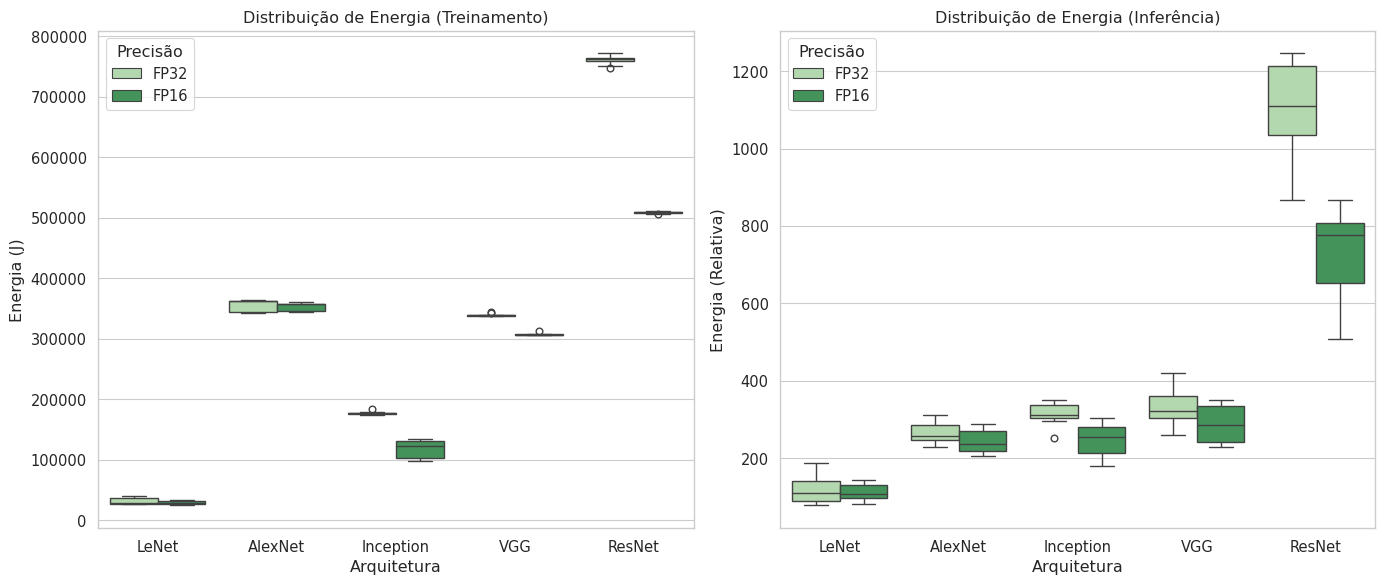

In [ ]:
# Geração de Boxplots para visualizar a significância
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot Treino
sns.boxplot(data=df_treino, x='Arquitetura', y='energy_consumed_joule', hue='Precisão', ax=axes[0], palette='Greens')
axes[0].set_title('Distribuição de Energia (Treinamento)')
axes[0].set_ylabel('Energia (J)')

# Boxplot Inferência
sns.boxplot(data=df_teste, x='Arquitetura', y='energy_consumed_joule', hue='Precisão', ax=axes[1], palette='Greens')
axes[1].set_title('Distribuição de Energia (Inferência)')
axes[1].set_ylabel('Energia (Relativa)')

plt.tight_layout()
plt.show()

In [ ]:
# # Gráfico Boxplot Global
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# # sns.boxplot(data=df_treino, x='Precisão', y='duration', ax=axes[0], palette='Greens') #Forma obsoleta
# # Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.
# # Assign the `x` variable to `hue` and set `legend=False` for the same effect.
# sns.boxplot(data=df_treino, y='duration', ax=axes[0], hue='Precisão', palette='Greens')
# axes[0].set_title('Duração Treinamento (Global)')

# sns.boxplot(data=df_inferencia, y='energy_consumed', ax=axes[1], hue='Precisão', palette='Greens')
# axes[1].set_title('Energia Inferência (Global)')

# sns.boxplot(data=df_inferencia, y='Accuracy', ax=axes[2], hue='Precisão', palette='Greens')
# axes[2].set_title('Acurácia (Global)')

# plt.tight_layout()
# plt.show()

## Gráfico radar

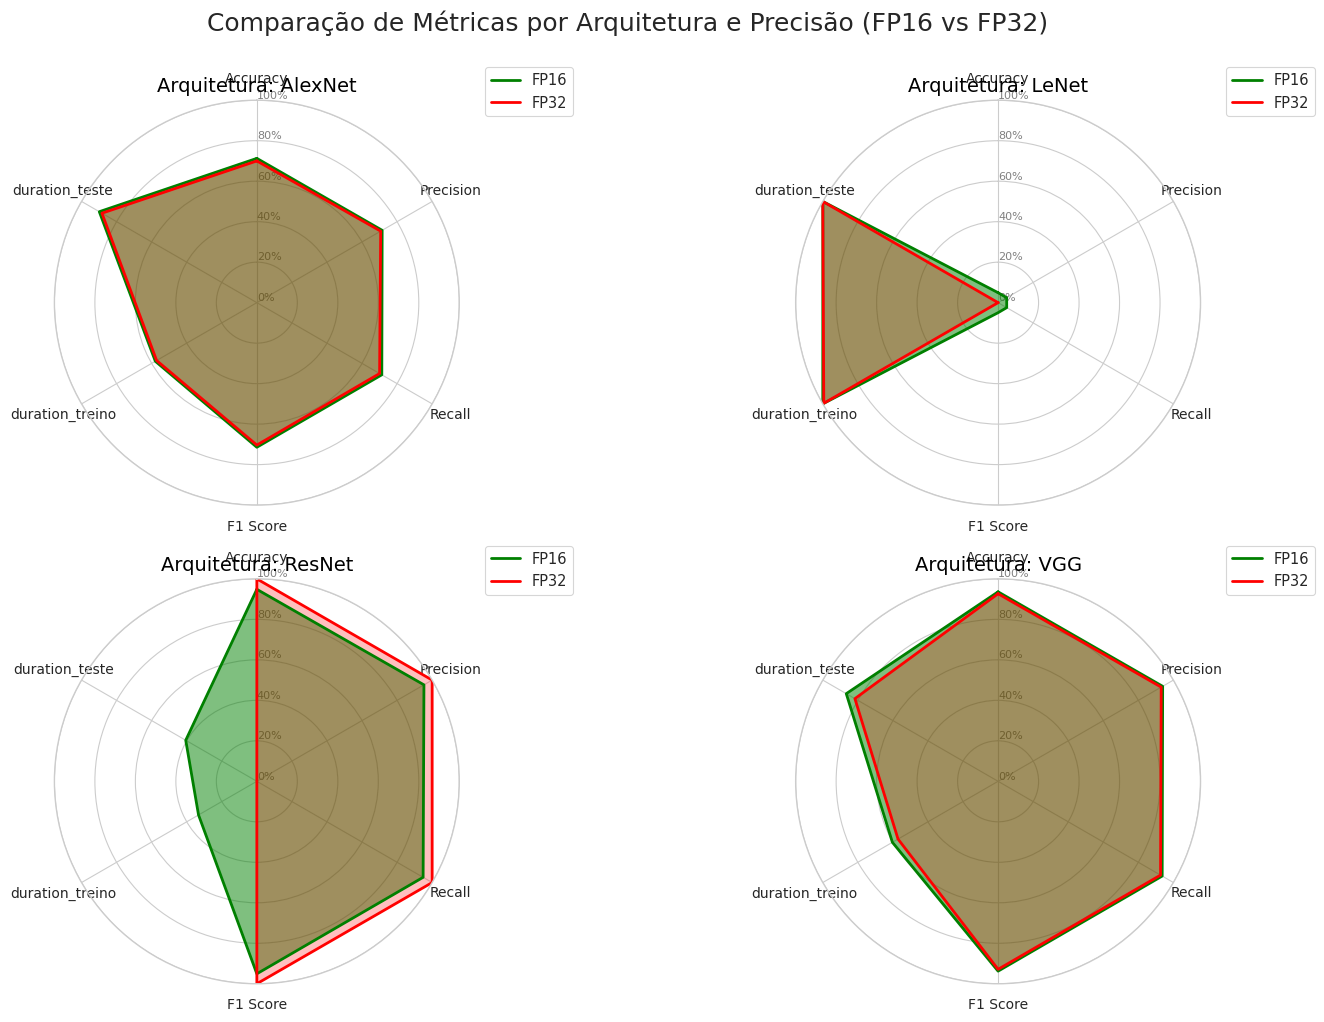

In [ ]:
# Define the metrics for the radar chart
performance_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
efficiency_metrics = ['duration_treino', 'duration_teste']
all_metrics = performance_metrics + efficiency_metrics

# Prepare a DataFrame for normalization and plotting
# We'll use df_final and unpivot it slightly to make normalization easier
df_radar = df_final.set_index(['Arquitetura', 'Precisão'])[all_metrics]

# Normalize the metrics
df_normalized = pd.DataFrame(index=df_radar.index, columns=df_radar.columns)

for metric in all_metrics:
    min_val = df_radar[metric].min()
    max_val = df_radar[metric].max()

    if metric in performance_metrics: # Higher is better
        df_normalized[metric] = (df_radar[metric] - min_val) / (max_val - min_val)
    else: # Efficiency metrics, lower is better, so invert the scale
        df_normalized[metric] = 1 - (df_radar[metric] - min_val) / (max_val - min_val)

# Define a function to create a single radar chart
def create_radar_chart(ax, data_fp16, data_fp32, categories, title):
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop

    # Plot FP16
    values_fp16 = data_fp16.tolist()
    values_fp16 += values_fp16[:1]
    ax.plot(angles, values_fp16, color='green', linewidth=2, linestyle='solid', label='FP16')
    ax.fill(angles, values_fp16, color='green', alpha=0.50)

    # Plot FP32
    values_fp32 = data_fp32.tolist()
    values_fp32 += values_fp32[:1]
    ax.plot(angles, values_fp32, color='red', linewidth=2, linestyle='solid', label='FP32')
    ax.fill(angles, values_fp32, color='red', alpha=0.25)


    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0)  # Offset the radial labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1) # All normalized values are between 0 and 1
    ax.set_yticks(np.linspace(0, 1, 6)) # Show 6 radial ticks
    ax.set_yticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)], color='gray', size=8)
    ax.set_title(title, size=14, color='black', position=(0.5, 1.1), ha='center')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Create radar charts for each architecture
architectures = df_final['Arquitetura'].unique()

fig, axes = plt.subplots(figsize=(15, 15), nrows=3, ncols=2,
                         subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, arch in enumerate(architectures):
    data_fp16 = df_normalized.loc[(arch, 'FP16'), all_metrics]
    data_fp32 = df_normalized.loc[(arch, 'FP32'), all_metrics]
    create_radar_chart(axes[i], data_fp16, data_fp32, all_metrics, f'Arquitetura: {arch}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('Comparação de Métricas por Arquitetura e Precisão (FP16 vs FP32)', fontsize=18, y=0.98)
plt.show()

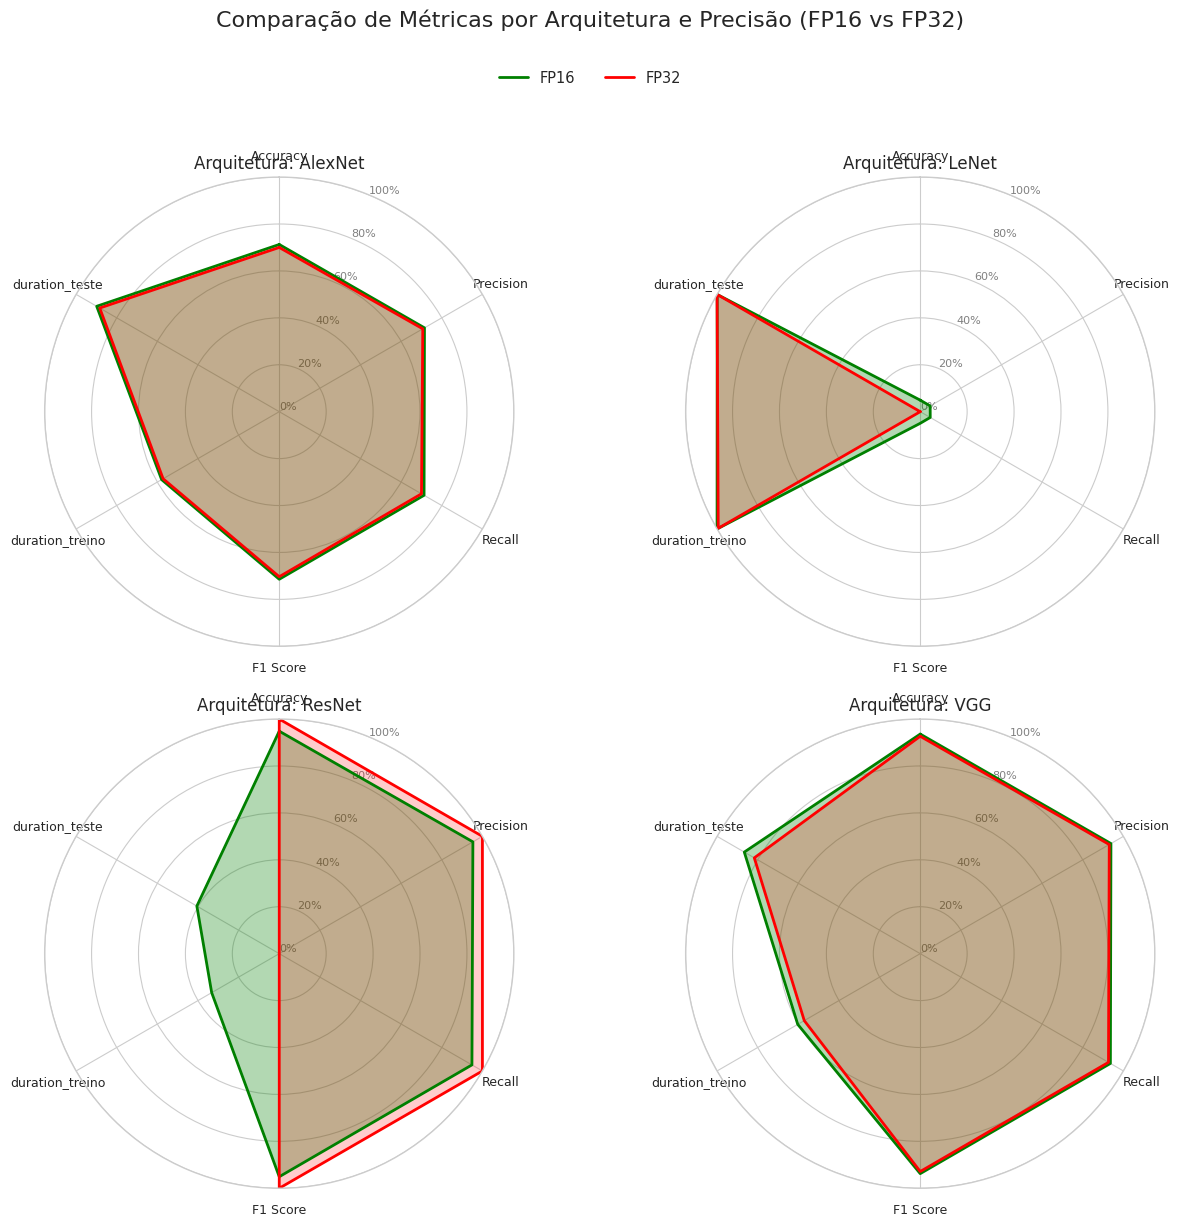

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

# -----------------------------
# Config
# -----------------------------
performance_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
efficiency_metrics  = ['duration_treino', 'duration_teste']
all_metrics = performance_metrics + efficiency_metrics

ARCH_COL = 'Arquitetura'
PREC_COL = 'Precisão'
FP16 = 'FP16'
FP32 = 'FP32'

# Cores fixas
COLOR_FP16 = 'green'
COLOR_FP32 = 'red'

# -----------------------------
# Validações básicas
# -----------------------------
required_cols = {ARCH_COL, PREC_COL, *all_metrics}
missing = required_cols - set(df_final.columns)
if missing:
    raise ValueError(f"df_final não contém as colunas obrigatórias: {sorted(missing)}")

df_work = df_final.copy()
for c in all_metrics:
    df_work[c] = pd.to_numeric(df_work[c], errors='coerce')

df_work = df_work.dropna(subset=all_metrics, how='all')

# -----------------------------
# Índice
# -----------------------------
df_radar = df_work.set_index([ARCH_COL, PREC_COL])[all_metrics].sort_index()

# -----------------------------
# Normalização robusta
# -----------------------------
df_normalized = pd.DataFrame(index=df_radar.index, columns=df_radar.columns, dtype=float)

for metric in all_metrics:
    s = df_radar[metric]

    if s.notna().sum() == 0:
        df_normalized[metric] = np.nan
        continue

    min_val = s.min(skipna=True)
    max_val = s.max(skipna=True)
    rng = max_val - min_val

    if rng == 0 or pd.isna(rng):
        df_normalized[metric] = 0.5
        continue

    scaled = (s - min_val) / rng

    if metric in efficiency_metrics:
        scaled = 1 - scaled

    df_normalized[metric] = scaled.clip(0, 1)

# -----------------------------
# Função Radar (cores fixas)
# -----------------------------
def create_radar_chart(ax, data_fp16, data_fp32, categories, title):
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    # FP16 - VERDE
    values_fp16 = data_fp16.to_list()
    values_fp16 += values_fp16[:1]
    ax.plot(angles, values_fp16, color=COLOR_FP16, linewidth=2, label=FP16)
    ax.fill(angles, values_fp16, color=COLOR_FP16, alpha=0.30)

    # FP32 - VERMELHO
    values_fp32 = data_fp32.to_list()
    values_fp32 += values_fp32[:1]
    ax.plot(angles, values_fp32, color=COLOR_FP32, linewidth=2, label=FP32)
    ax.fill(angles, values_fp32, color=COLOR_FP32, alpha=0.20)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)

    ax.set_ylim(0, 1)
    yt = np.linspace(0, 1, 6)
    ax.set_yticks(yt)
    ax.set_yticklabels([f'{int(v*100)}%' for v in yt], color='gray', size=8)

    ax.set_title(title, size=12, position=(0.5, 1.12), ha='center')

# -----------------------------
# Grid dinâmico
# -----------------------------
architectures = df_work[ARCH_COL].dropna().unique().tolist()
n_arch = len(architectures)

ncols = 2 if n_arch <= 8 else 3
nrows = ceil(n_arch / ncols)

fig, axes = plt.subplots(
    figsize=(6.5 * ncols, 6.0 * nrows),
    nrows=nrows,
    ncols=ncols,
    subplot_kw=dict(polar=True)
)

axes = np.atleast_1d(axes).flatten()

plotted_any = False
for i, arch in enumerate(architectures):
    idx_fp16 = (arch, FP16)
    idx_fp32 = (arch, FP32)

    if idx_fp16 not in df_normalized.index or idx_fp32 not in df_normalized.index:
        fig.delaxes(axes[i])
        continue

    data_fp16 = df_normalized.loc[idx_fp16, all_metrics]
    data_fp32 = df_normalized.loc[idx_fp32, all_metrics]

    if data_fp16.isna().all() and data_fp32.isna().all():
        fig.delaxes(axes[i])
        continue

    create_radar_chart(axes[i], data_fp16, data_fp32, all_metrics,
                       f'Arquitetura: {arch}')
    plotted_any = True

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

if not plotted_any:
    raise ValueError("Nenhum radar foi plotado.")

# Legenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center',
           ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.98))

fig.suptitle('Comparação de Métricas por Arquitetura e Precisão (FP16 vs FP32)',
             fontsize=16, y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

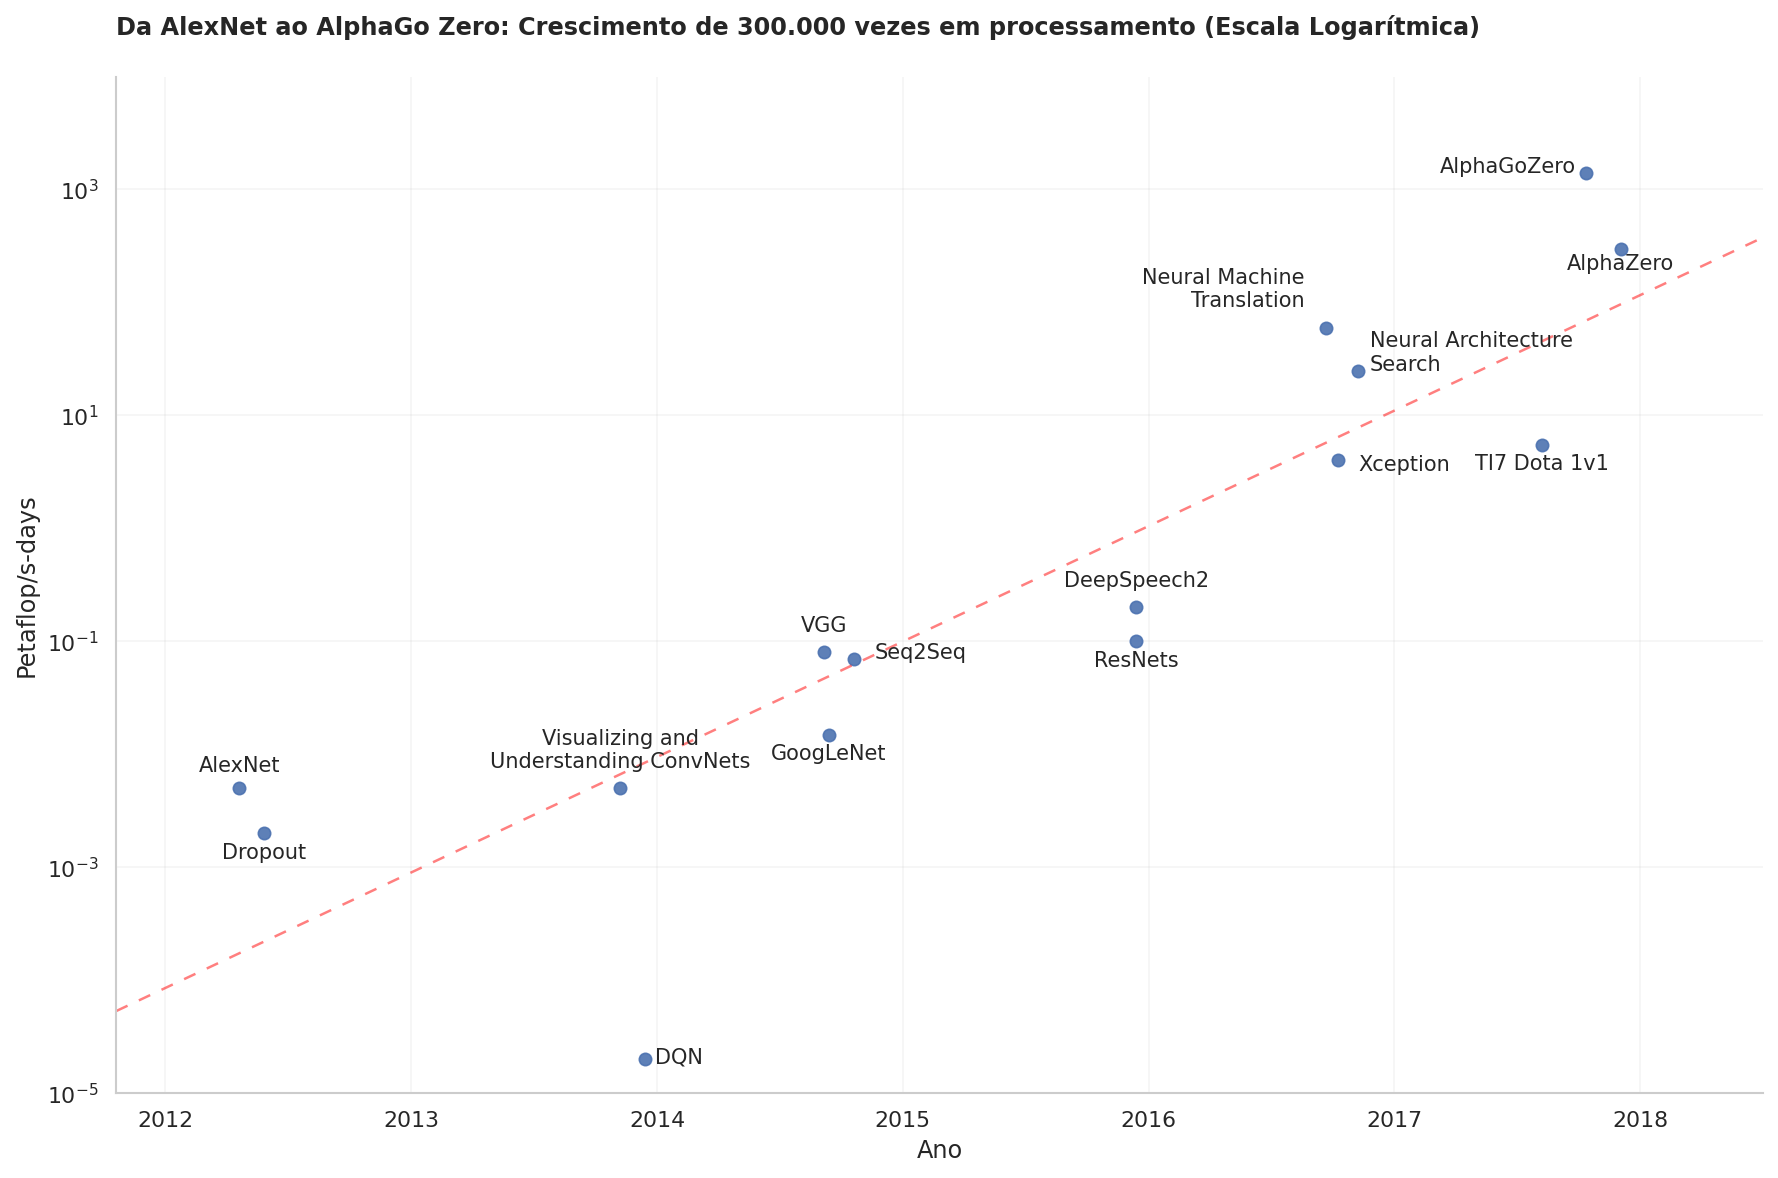

In [ ]:
# =========================
# Dados aproximados da figura
# =========================
data = [
    {"Year": 2012.3, "Compute": 5e-3,   "Label": "AlexNet"},
    {"Year": 2012.4, "Compute": 2e-3,   "Label": "Dropout"},
    {"Year": 2013.85,"Compute": 5e-3,   "Label": "Visualizing and\nUnderstanding ConvNets"},
    {"Year": 2013.95,"Compute": 2e-5,   "Label": "DQN"},
    {"Year": 2014.68,"Compute": 8e-2,   "Label": "VGG"},
    {"Year": 2014.70,"Compute": 1.5e-2, "Label": "GoogLeNet"},
    {"Year": 2014.80,"Compute": 7e-2,   "Label": "Seq2Seq"},
    {"Year": 2015.95,"Compute": 1e-1,   "Label": "ResNets"},
    {"Year": 2015.95,"Compute": 2e-1,   "Label": "DeepSpeech2"},
    {"Year": 2016.77,"Compute": 4,      "Label": "Xception"},
    {"Year": 2016.85,"Compute": 25,     "Label": "Neural Architecture\nSearch"},
    {"Year": 2016.72,"Compute": 60,     "Label": "Neural Machine\nTranslation"},
    {"Year": 2017.60,"Compute": 5.5,    "Label": "TI7 Dota 1v1"},
    {"Year": 2017.92,"Compute": 300,    "Label": "AlphaZero"},
    {"Year": 2017.78,"Compute": 1400,   "Label": "AlphaGoZero"},
]

df = pd.DataFrame(data)

# =========================
# Figura
# =========================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

# Dispersão
ax.scatter(df["Year"], df["Compute"], s=35, alpha=0.9)

# Escala log no eixo Y
ax.set_yscale("log")

# Limites dos eixos
ax.set_xlim(2011.8, 2018.5)
ax.set_ylim(1e-5, 1e4)

# Título e rótulos
ax.set_title("Da AlexNet ao AlphaGo Zero: Crescimento de 300.000 vezes em processamento (Escala Logarítmica)",
             loc="left", fontweight="bold", pad=20)
ax.set_ylabel("Petaflop/s-days")
ax.set_xlabel("Ano")

# Grade
ax.grid(True, which="both", linestyle="-", alpha=0.2)

# =========================
# Linha de tendência aproximada
# =========================
# Ajuste linear sobre log10(Compute)
x = df["Year"].values
y = np.log10(df["Compute"].values)

coef = np.polyfit(x, y, 1)
x_line = np.linspace(2011.8, 2018.5, 300)
y_line = 10 ** (coef[0] * x_line + coef[1])

ax.plot(x_line, y_line, linestyle=(0, (5, 5)), alpha=0.5, color='red')

# Texto da linha
# ax.text(2013.05, 7e-4, "3.4-month doubling", fontsize=11, alpha=0.7)

# =========================
# Anotações dos pontos
# =========================
offsets = {
    "AlexNet": (0, 8),
    "Dropout": (0, -12),
    "Visualizing and\nUnderstanding ConvNets": (0, 10),
    "DQN": (5, -2),
    "VGG": (0, 10),
    "GoogLeNet": (0, -12),
    "Seq2Seq": (10, 0),
    "ResNets": (0, -12),
    "DeepSpeech2": (0, 10),
    "Xception": (10, -5),
    "Neural Architecture\nSearch": (6, 0),
    "Neural Machine\nTranslation": (-10, 10),
    "TI7 Dota 1v1": (0, -12),
    "AlphaZero": (0, -10),
    "AlphaGoZero": (-5, 0),
}

for _, row in df.iterrows():
    dx, dy = offsets.get(row["Label"], (5, 5))
    ax.annotate(
        row["Label"],
        (row["Year"], row["Compute"]),
        textcoords="offset points",
        xytext=(dx, dy),
        ha="center" if dx == 0 else ("left" if dx > 0 else "right"),
        fontsize=10
    )

# Remover bordas superiores e direita para ficar mais limpo
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

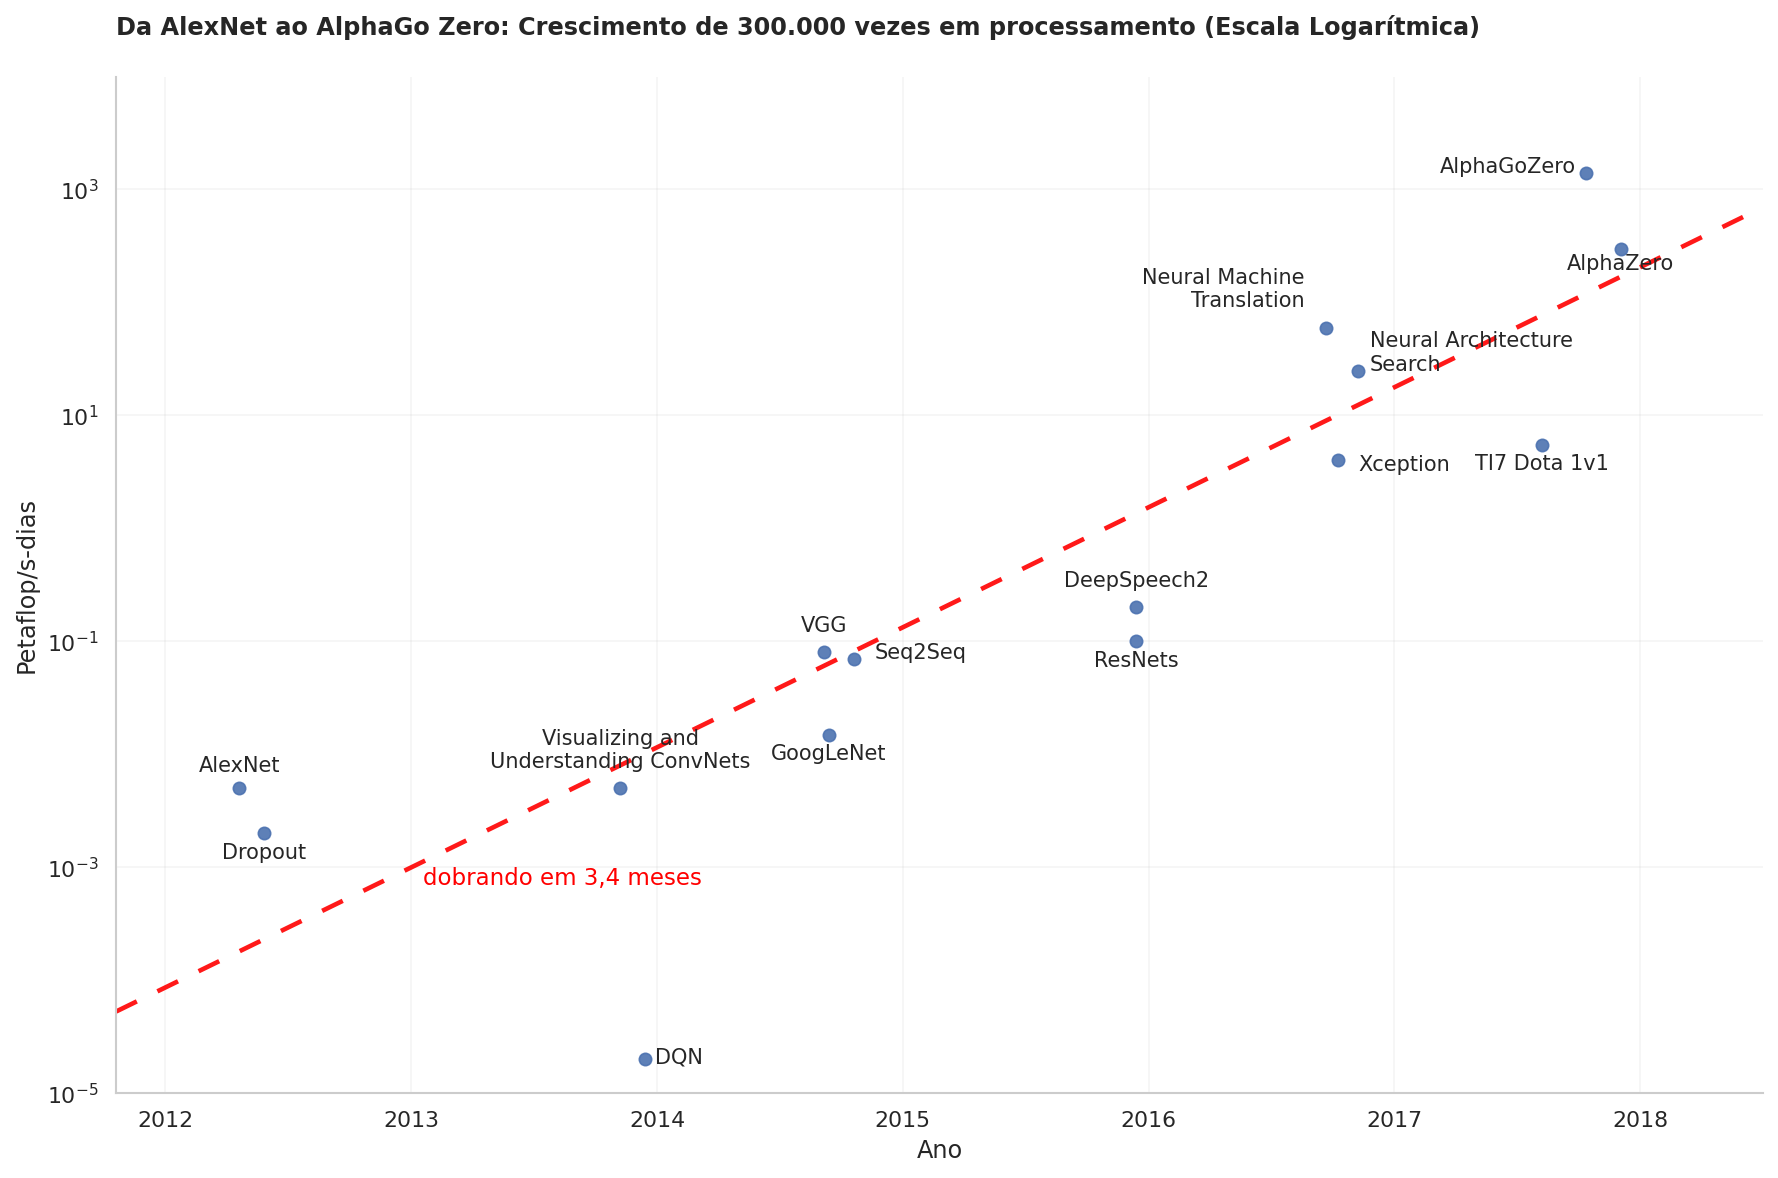

In [ ]:
data = [
    {"Year": 2012.3, "Compute": 5e-3,   "Label": "AlexNet"},
    {"Year": 2012.4, "Compute": 2e-3,   "Label": "Dropout"},
    {"Year": 2013.85,"Compute": 5e-3,   "Label": "Visualizing and\nUnderstanding ConvNets"},
    {"Year": 2013.95,"Compute": 2e-5,   "Label": "DQN"},
    {"Year": 2014.68,"Compute": 8e-2,   "Label": "VGG"},
    {"Year": 2014.70,"Compute": 1.5e-2, "Label": "GoogLeNet"},
    {"Year": 2014.80,"Compute": 7e-2,   "Label": "Seq2Seq"},
    {"Year": 2015.95,"Compute": 1e-1,   "Label": "ResNets"},
    {"Year": 2015.95,"Compute": 2e-1,   "Label": "DeepSpeech2"},
    {"Year": 2016.77,"Compute": 4,      "Label": "Xception"},
    {"Year": 2016.85,"Compute": 25,     "Label": "Neural Architecture\nSearch"},
    {"Year": 2016.72,"Compute": 60,     "Label": "Neural Machine\nTranslation"},
    {"Year": 2017.60,"Compute": 5.5,    "Label": "TI7 Dota 1v1"},
    {"Year": 2017.92,"Compute": 300,    "Label": "AlphaZero"},
    {"Year": 2017.78,"Compute": 1400,   "Label": "AlphaGoZero"},
]

df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

ax.scatter(df["Year"], df["Compute"], s=35, alpha=0.9)
ax.set_yscale("log")

ax.set_xlim(2011.8, 2018.5)
ax.set_ylim(1e-5, 1e4)

ax.set_title(
    "Da AlexNet ao AlphaGo Zero: Crescimento de 300.000 vezes em processamento (Escala Logarítmica)",
    loc="left",
    fontweight="bold",
    pad=20
)
ax.set_ylabel("Petaflop/s-dias")
ax.set_xlabel("Ano")

ax.grid(True, which="both", linestyle="-", alpha=0.2)

# Linha fixa com duplicação a cada 3.4 meses
t0 = 2013.0
y0 = 1e-3
doubling_months = 3.4
doubling_years = doubling_months / 12.0

x_line = np.linspace(2011.8, 2018.5, 400)
y_line = y0 * (2 ** ((x_line - t0) / doubling_years))

ax.plot(
    x_line,
    y_line,
    linestyle=(0, (5, 5)),
    linewidth=2.2,
    color="red",
    alpha=0.9
)

ax.text(2013.05, 7e-4, "dobrando em 3,4 meses", fontsize=11, color="red")

offsets = {
    "AlexNet": (0, 8),
    "Dropout": (0, -12),
    "Visualizing and\nUnderstanding ConvNets": (0, 10),
    "DQN": (5, -2),
    "VGG": (0, 10),
    "GoogLeNet": (0, -12),
    "Seq2Seq": (10, 0),
    "ResNets": (0, -12),
    "DeepSpeech2": (0, 10),
    "Xception": (10, -5),
    "Neural Architecture\nSearch": (6, 0),
    "Neural Machine\nTranslation": (-10, 10),
    "TI7 Dota 1v1": (0, -12),
    "AlphaZero": (0, -10),
    "AlphaGoZero": (-5, 0),
}

for _, row in df.iterrows():
    dx, dy = offsets.get(row["Label"], (5, 5))
    ax.annotate(
        row["Label"],
        (row["Year"], row["Compute"]),
        textcoords="offset points",
        xytext=(dx, dy),
        ha="center" if dx == 0 else ("left" if dx > 0 else "right"),
        fontsize=10
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()